# Evaluación experimental y análisis numérico del sistema de recomendación

Este notebook evalúa cuantitativamente el sistema de recomendación de películas Peach bajo un escenario de usuario nuevo o *cold start*.

A diferencia del notebook principal, aquí no se ejecutan el onboarding interactivo, la identidad cinéfila, la búsqueda de usuarios afines, la evidencia social ni el Mapa de Afinidades. El propósito de este notebook es evaluar de manera aislada la capacidad de recomendación del modelo basado en descomposición en valores singulares truncada, así como estudiar sus propiedades numéricas y computacionales.

## Protocolo experimental

La evaluación utiliza una separación por usuarios:

- El 70 % de los usuarios se emplea para construir la matriz de entrenamiento y calcular la SVD truncada.
- El 30 % restante queda completamente excluido del entrenamiento y se utiliza como conjunto de prueba.
- Para cada usuario evaluado se revelan exactamente cinco ratings.
- Los demás ratings del usuario se mantienen ocultos.
- Las películas ocultas con rating mayor o igual que 4.0 se consideran relevantes.
- Peach genera un ranking Top-10 que se compara con las películas positivas ocultas.
- El modelo se compara contra un baseline no personalizado basado en popularidad.

La separación se realiza por usuarios y no por interacciones individuales. De esta manera, ningún rating perteneciente a los usuarios de prueba participa en la construcción de los factores latentes, lo que evita fuga de información.

## Métricas de recomendación

Las métricas principales son:

- HitRate@10.
- Precision@10.
- Recall@10.
- NDCG@10.
- Cobertura del catálogo.

Las métricas se calculan tanto para Peach como para el baseline de popularidad. Además, se analiza la diferencia emparejada entre ambos modelos, dado que se evalúan sobre los mismos usuarios y los mismos conjuntos de películas ocultas.

## Análisis numérico

Además de la evaluación del ranking, se estudian las propiedades numéricas del modelo mediante:

- Espectro singular de la matriz de entrenamiento.
- Decaimiento logarítmico de los valores singulares.
- Aporte individual de energía de cada componente.
- Energía acumulada capturada por la SVD truncada.
- Error relativo estimado de reconstrucción.
- Número de condición de los sistemas sin regularización.
- Número de condición de los sistemas regularizados.
- Sensibilidad del condicionamiento respecto al parámetro de regularización $\lambda$.

## Sensibilidad respecto a la dimensión latente

Se evalúa el comportamiento del sistema para distintos valores de la dimensión latente $k$. Para cada configuración se estudian:

- HitRate@10.
- Precision@10.
- Recall@10.
- NDCG@10.
- Cobertura del catálogo.
- Energía capturada.
- Error relativo de reconstrucción.
- Tiempo de cálculo de la SVD.
- Tiempo promedio de recomendación por usuario.
- Condicionamiento de los sistemas utilizados para estimar usuarios nuevos.

Este análisis permite estudiar el equilibrio entre calidad de recomendación, estabilidad numérica y costo computacional.

In [59]:
# ============================================================
# SISTEMA DE VISUALIZACIÓN CIENTÍFICA DE PEACH
# ============================================================

from pathlib import Path
from cycler import cycler

import re
import shutil
import unicodedata

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.ticker import (
    FuncFormatter,
    ScalarFormatter,
    LogLocator,
    NullFormatter,
    PercentFormatter
)


# ============================================================
# PALETA CIENTÍFICA Y ACCESIBLE
# ============================================================

# Colores inspirados en la paleta Okabe–Ito.
# Mantienen contraste razonable bajo deficiencias rojo-verde.

PEACH_ORANGE = "#D55E00"
PEACH_ORANGE_LIGHT = "#E69F00"

POPULARITY_BLUE = "#0072B2"
PEACH_SKY = "#56B4E9"

PEACH_GREEN = "#009E73"
PEACH_PURPLE = "#CC79A7"

PEACH_DARK = "#222222"
PEACH_GRAY = "#6B7280"
PEACH_LIGHT_GRAY = "#D1D5DB"
PEACH_BACKGROUND = "#FFFFFF"


# ============================================================
# CARPETA DE SALIDA
# ============================================================

GRAPH_DIR = Path(
    "/content/graficas_peach_final"
)

if GRAPH_DIR.exists():
    shutil.rmtree(
        GRAPH_DIR
    )

GRAPH_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# CONFIGURACIÓN GLOBAL DE MATPLOTLIB
# ============================================================

plt.rcParams.update({
    # --------------------------------------------------------
    # Tipografía
    # --------------------------------------------------------

    "font.family": "serif",

    "font.serif": [
        "DejaVu Serif",
        "Times New Roman",
        "STIXGeneral"
    ],

    # Renderizado matemático compatible con LaTeX.
    # No se activa text.usetex para evitar dependencias
    # externas y errores de compilación en Google Colab.
    "mathtext.fontset": "stix",
    "text.usetex": False,

    "font.size": 14,

    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "axes.titleweight": "semibold",

    "axes.labelpad": 8,
    "axes.titlepad": 14,

    # --------------------------------------------------------
    # Ejes
    # --------------------------------------------------------

    "axes.linewidth": 0.8,
    "axes.edgecolor": PEACH_DARK,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "axes.axisbelow": True,
    "axes.unicode_minus": True,

    # Notación científica usando símbolos matemáticos.
    "axes.formatter.use_mathtext": True,

    # --------------------------------------------------------
    # Ticks
    # --------------------------------------------------------

    "xtick.labelsize": 12,
    "ytick.labelsize": 12,

    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    "xtick.direction": "in",
    "ytick.direction": "in",

    "xtick.major.size": 6,
    "ytick.major.size": 6,

    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "xtick.minor.width": 0.6,
    "ytick.minor.width": 0.6,

    # --------------------------------------------------------
    # Líneas y marcadores
    # --------------------------------------------------------

    "lines.linewidth": 2.0,
    "lines.markersize": 6,

    "axes.prop_cycle": cycler(
        color=[
            PEACH_ORANGE,
            POPULARITY_BLUE,
            PEACH_GREEN,
            PEACH_PURPLE,
            PEACH_ORANGE_LIGHT
        ]
    ),

    # --------------------------------------------------------
    # Cuadrícula
    # --------------------------------------------------------

    "axes.grid": False,

    "grid.color": PEACH_GRAY,
    "grid.linewidth": 0.4,
    "grid.alpha": 0.28,
    "grid.linestyle": "--",

    # --------------------------------------------------------
    # Leyendas
    # --------------------------------------------------------

    "legend.frameon": False,
    "legend.fontsize": 11,

    # --------------------------------------------------------
    # Figuras y exportación
    # --------------------------------------------------------

    "figure.dpi": 120,
    "figure.facecolor": PEACH_BACKGROUND,

    "axes.facecolor": PEACH_BACKGROUND,

    "savefig.facecolor": PEACH_BACKGROUND,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "savefig.pad_inches": 0.06
})


# ============================================================
# FUNCIONES AUXILIARES
# ============================================================

def limpiar_nombre_grafica(nombre):
    """
    Convierte el nombre de una figura en un nombre de
    archivo válido y reproducible.
    """

    nombre = unicodedata.normalize(
        "NFKD",
        str(nombre)
    )

    nombre = (
        nombre
        .encode(
            "ascii",
            "ignore"
        )
        .decode("ascii")
        .lower()
    )

    nombre = re.sub(
        r"[^a-z0-9]+",
        "_",
        nombre
    )

    return nombre.strip("_") or "grafica"


def aplicar_estilo_cientifico(
    ax,
    eje_cuadricula="both",
    cuadricula_menor=False
):
    """
    Aplica una cuadrícula discreta y ticks científicos
    sin alterar los datos ni la escala de la figura.
    """

    ax.set_axisbelow(True)

    ax.grid(
        True,
        which="major",
        axis=eje_cuadricula,
        linestyle="--",
        linewidth=0.4,
        alpha=0.28
    )

    if cuadricula_menor:
        ax.grid(
            True,
            which="minor",
            axis=eje_cuadricula,
            linestyle=":",
            linewidth=0.3,
            alpha=0.14
        )

    ax.tick_params(
        which="major",
        direction="in",
        length=6
    )

    ax.tick_params(
        which="minor",
        direction="in",
        length=3
    )


def configurar_eje_log_x(
    ax,
    ticks
):
    """
    Configura un eje x logarítmico manteniendo visibles
    los valores concretos utilizados en el experimento.
    """

    ax.set_xscale("log")

    ax.set_xticks(
        ticks
    )

    ax.xaxis.set_major_formatter(
        ScalarFormatter()
    )

    ax.xaxis.set_minor_locator(
        LogLocator(
            base=10,
            subs=np.arange(
                2,
                10
            )
            * 0.1
        )
    )

    ax.xaxis.set_minor_formatter(
        NullFormatter()
    )


def construir_bins_logaritmicos(
    values,
    n_bins=20
):
    """
    Construye intervalos geométricos para histogramas
    cuyo eje horizontal se representará en escala log.
    """

    values = np.asarray(
        values,
        dtype=np.float64
    )

    positive_values = values[
        np.isfinite(values)
        & (values > 0)
    ]

    if positive_values.size == 0:
        raise ValueError(
            "No existen valores positivos y finitos."
        )

    minimum = float(
        positive_values.min()
    )

    maximum = float(
        positive_values.max()
    )

    if np.isclose(
        minimum,
        maximum
    ):
        minimum /= 1.10
        maximum *= 1.10

    return np.geomspace(
        minimum,
        maximum,
        n_bins + 1
    )


def guardar_y_mostrar(nombre):
    """
    Guarda la figura activa en:

    - PNG de 300 dpi;
    - PDF vectorial para LaTeX.

    Después muestra la figura y libera su memoria.
    """

    figura = plt.gcf()

    if not figura.axes:
        raise RuntimeError(
            "No existe una figura activa para guardar."
        )

    nombre_limpio = limpiar_nombre_grafica(
        nombre
    )

    ruta_png = (
        GRAPH_DIR
        / f"{nombre_limpio}.png"
    )

    ruta_pdf = (
        GRAPH_DIR
        / f"{nombre_limpio}.pdf"
    )

    figura.savefig(
        ruta_png,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    figura.savefig(
        ruta_pdf,
        format="pdf",
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()

    plt.close(
        figura
    )

    print(
        "Gráfica guardada:",
        ruta_png.name,
        "y",
        ruta_pdf.name
    )

    return ruta_png


print(
    "✅ Sistema científico de gráficas preparado."
)

print(
    "Carpeta:",
    GRAPH_DIR
)

✅ Sistema científico de gráficas preparado.
Carpeta: /content/graficas_peach_final


## 1. Configuración e importaciones

En esta sección se cargan las librerías y se establecen los parámetros generales del sistema.

In [60]:
# ============================================================
# IMPORTACIONES
# ============================================================

import os
import gc
import time
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

from IPython.display import display


In [61]:
# ============================================================
# CONFIGURACIÓN EXPERIMENTAL
# ============================================================

# ------------------------------------------------------------
# Modelo SVD
# ------------------------------------------------------------

# Dimensión del espacio latente
K = 50

# Regularización para estimar usuarios nuevos
LAMBDA_REG = 0.1

# ------------------------------------------------------------
# División por usuarios
# ------------------------------------------------------------

TRAIN_USER_FRACTION = 0.70
TEST_USER_FRACTION = 0.30

# ------------------------------------------------------------
# Simulación del cold start
# ------------------------------------------------------------

# Ratings revelados al sistema
N_OBSERVED_RATINGS = 5

# Un usuario necesita suficientes ratings para revelar cinco
# y conservar información oculta para la evaluación
MIN_TEST_USER_RATINGS = 10

# Una película oculta es relevante cuando su rating es >= 4.0
POSITIVE_THRESHOLD = 4.0

# Tamaño del ranking evaluado
TOP_K = 10

# ------------------------------------------------------------
# Costo experimental
# ------------------------------------------------------------

# Se evaluará una muestra reproducible de usuarios válidos.
# Puede aumentarse después de verificar tiempos y memoria.
N_EVALUATION_USERS = 500

# ------------------------------------------------------------
# Estudios numéricos adicionales
# ------------------------------------------------------------

# Valores de k para estudiar la sensibilidad del modelo
K_STUDY_VALUES = [
    10,
    20,
    30,
    50,
    75,
    100
]

# Valores usados exclusivamente para medir el costo temporal de calcular la SVD
K_TIMING_VALUES = [
    10,
    20,
    50,
    100,
    200
]

# Usuarios empleados en el análisis según k.
# Se usa una muestra menor para controlar el costo.
N_K_STUDY_USERS = 100

# Usuarios utilizados para estudiar condicionamiento
N_CONDITION_USERS = 100

# Valores positivos de lambda para analizar regularización
LAMBDA_STUDY_VALUES = [
    1e-6,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1.0
]

# ------------------------------------------------------------
# Reproducibilidad
# ------------------------------------------------------------

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

print("Configuración experimental preparada.")
print("K:", K)
print("Lambda:", LAMBDA_REG)
print("Split:", TRAIN_USER_FRACTION, "/", TEST_USER_FRACTION)
print("Ratings observados por usuario:", N_OBSERVED_RATINGS)
print("Top-K:", TOP_K)

Configuración experimental preparada.
K: 50
Lambda: 0.1
Split: 0.7 / 0.3
Ratings observados por usuario: 5
Top-K: 10


## 2. Descarga y lectura de MovieLens 32M

La evaluación utiliza los archivos `movies.csv` y `ratings.csv` del conjunto de datos MovieLens 32M.

In [62]:
# ============================================================
# DESCARGA Y LECTURA DEL DATASET
# ============================================================

url = (
    "https://files.grouplens.org/"
    "datasets/movielens/ml-32m.zip"
)

zip_path = "/content/ml-32m.zip"
extract_path = "/content"
dataset_path = "/content/ml-32m"

# Descargar únicamente cuando el archivo no existe.
if not os.path.exists(zip_path):
    print("Descargando MovieLens 32M...")

    urllib.request.urlretrieve(
        url,
        zip_path
    )

else:
    print("El archivo ZIP ya está disponible.")

# Extraer únicamente cuando la carpeta no existe.
if not os.path.exists(dataset_path):
    print("Extrayendo MovieLens 32M...")

    with zipfile.ZipFile(
        zip_path,
        "r"
    ) as zip_ref:
        zip_ref.extractall(
            extract_path
        )

else:
    print("El dataset ya está extraído.")

movies = pd.read_csv(
    f"{dataset_path}/movies.csv"
)

ratings = pd.read_csv(
    f"{dataset_path}/ratings.csv"
)

print("\nDatos originales cargados:")
print("movies:", movies.shape)
print("ratings:", ratings.shape)

display(movies.head())
display(ratings.head())

El archivo ZIP ya está disponible.
El dataset ya está extraído.

Datos originales cargados:
movies: (87585, 3)
ratings: (32000204, 4)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


## 3. Limpieza y validación

Se eliminan registros incompletos, ratings fuera del intervalo permitido y duplicados usuario–película.

Cuando un usuario presenta más de un registro para una misma película, se conserva la interacción más reciente según el timestamp.

Finalmente, los ratings se limitan a películas presentes en el catálogo limpio.

In [63]:
# ============================================================
# LIMPIEZA DE PELÍCULAS
# ============================================================

movies_clean = (
    movies
    .dropna(
        subset=[
            "movieId",
            "title",
            "genres"
        ]
    )
    .drop_duplicates(
        subset=["movieId"],
        keep="last"
    )
    [
        [
            "movieId",
            "title",
            "genres"
        ]
    ]
    .copy()
)

movies_clean["movieId"] = (
    movies_clean["movieId"]
    .astype(np.int64)
)


# ============================================================
# LIMPIEZA DE RATINGS
# ============================================================

ratings_clean = (
    ratings
    .dropna(
        subset=[
            "userId",
            "movieId",
            "rating"
        ]
    )
    .copy()
)

ratings_clean = ratings_clean[
    ratings_clean["rating"].between(
        0.5,
        5.0
    )
].copy()

# Conservar el rating más reciente en caso
# de encontrar pares usuario-película repetidos.
if "timestamp" in ratings_clean.columns:
    ratings_clean = (
        ratings_clean
        .sort_values("timestamp")
        .drop_duplicates(
            subset=[
                "userId",
                "movieId"
            ],
            keep="last"
        )
    )

else:
    ratings_clean = (
        ratings_clean
        .drop_duplicates(
            subset=[
                "userId",
                "movieId"
            ],
            keep="last"
        )
    )

ratings_clean = ratings_clean[
    [
        "userId",
        "movieId",
        "rating"
    ]
].copy()

ratings_clean["userId"] = (
    ratings_clean["userId"]
    .astype(np.int64)
)

ratings_clean["movieId"] = (
    ratings_clean["movieId"]
    .astype(np.int64)
)

ratings_clean["rating"] = (
    ratings_clean["rating"]
    .astype(np.float32)
)


# ============================================================
# CONSISTENCIA CON EL CATÁLOGO
# ============================================================

valid_movie_ids = set(
    movies_clean["movieId"]
    .tolist()
)

ratings_clean = ratings_clean[
    ratings_clean["movieId"].isin(
        valid_movie_ids
    )
].reset_index(drop=True)


# ============================================================
# VALIDACIONES
# ============================================================

duplicate_pairs = int(
    ratings_clean.duplicated(
        subset=[
            "userId",
            "movieId"
        ]
    ).sum()
)

assert duplicate_pairs == 0

assert ratings_clean["rating"].between(
    0.5,
    5.0
).all()

print("Datos limpios:")
print("Películas:", len(movies_clean))
print("Ratings:", len(ratings_clean))

print(
    "Usuarios:",
    ratings_clean["userId"].nunique()
)

print(
    "Películas con ratings:",
    ratings_clean["movieId"].nunique()
)

print(
    "Pares usuario-película duplicados:",
    duplicate_pairs
)

Datos limpios:
Películas: 87585
Ratings: 32000204
Usuarios: 200948
Películas con ratings: 84432
Pares usuario-película duplicados: 0


## 4. Descripción general de los ratings

Antes de dividir los usuarios se revisa la distribución de las calificaciones y la cantidad de interacciones por usuario.

Este análisis permite conocer el tamaño y la dispersión del problema, pero no interviene en la separación de entrenamiento y prueba.

,rating,count
0,0.5,525132
1,1.0,946675
2,1.5,531063
3,2.0,2028622
4,2.5,1685386
5,3.0,6054990
6,3.5,4290105
7,4.0,8367654
8,4.5,2974000
9,5.0,4596577


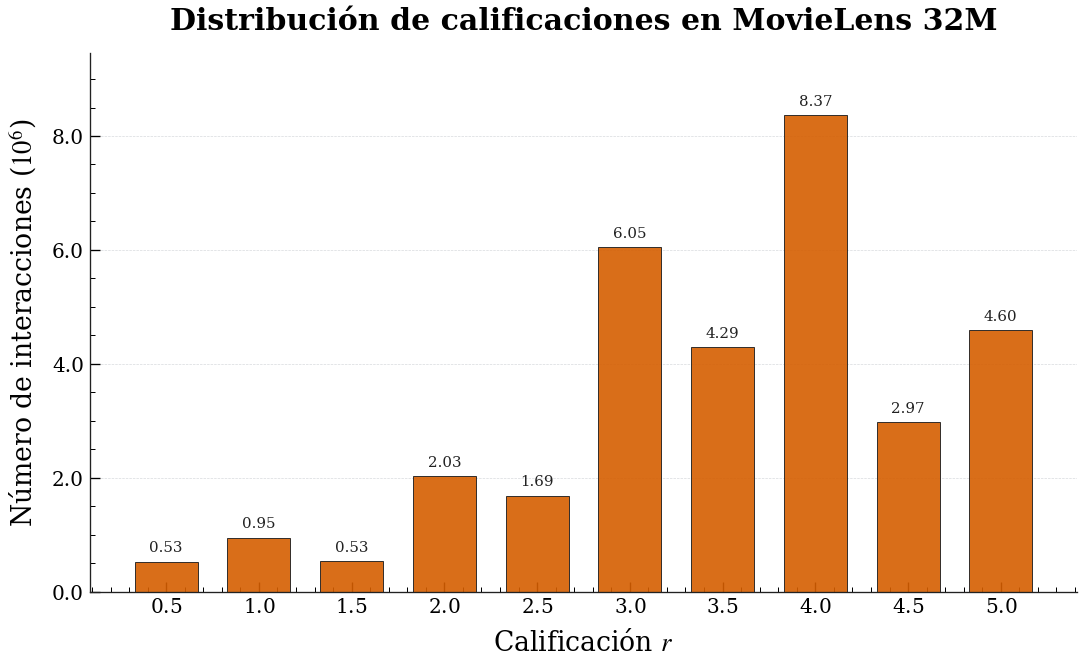

Gráfica guardada: 01_distribucion_ratings.png y 01_distribucion_ratings.pdf


PosixPath('/content/graficas_peach_final/01_distribucion_ratings.png')

In [64]:
# ============================================================
# DISTRIBUCIÓN DE RATINGS
# ============================================================

rating_distribution = (
    ratings_clean
    .groupby("rating")
    .size()
    .reset_index(name="count")
    .sort_values("rating")
)

display(rating_distribution)

fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained"
)

bars = ax.bar(
    rating_distribution["rating"],
    rating_distribution["count"],
    width=0.34,
    color=PEACH_ORANGE,
    edgecolor=PEACH_DARK,
    linewidth=0.6,
    alpha=0.90
)

ax.set_xlabel(
    r"Calificación $r$"
)

ax.set_ylabel(
    r"Número de interacciones ($10^6$)"
)

ax.set_title(
    "Distribución de calificaciones en MovieLens 32M"
)

ax.set_xticks(
    rating_distribution["rating"]
)

ax.set_ylim(
    0,
    1.13
    * rating_distribution[
        "count"
    ].max()
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f"{value / 1e6:.1f}"
    )
)

for bar, count in zip(
    bars,
    rating_distribution["count"]
):
    ax.annotate(
        f"{count / 1e6:.2f}",
        xy=(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        color=PEACH_DARK
    )

aplicar_estilo_cientifico(
    ax,
    eje_cuadricula="y"
)

guardar_y_mostrar(
    "01_distribucion_ratings"
)

## 5. División del 70 % y 30 % por usuarios

La separación se realiza sobre identificadores de usuarios, no sobre filas individuales de ratings.

El 70 % de los usuarios se utiliza para construir el modelo. El 30 % restante queda completamente excluido de la matriz de entrenamiento.

Por tanto, ningún rating de los usuarios de prueba participa en el cálculo de la SVD. Esta condición es necesaria para simular correctamente el ingreso de usuarios nuevos y evitar fuga de información.

In [65]:
# ============================================================
# DIVISIÓN REPRODUCIBLE POR USUARIOS
# ============================================================

all_user_ids = np.sort(
    ratings_clean["userId"]
    .unique()
)

rng = np.random.default_rng(
    RANDOM_STATE
)

shuffled_user_ids = rng.permutation(
    all_user_ids
)

n_total_users = len(
    shuffled_user_ids
)

n_train_users = int(
    np.floor(
        TRAIN_USER_FRACTION
        * n_total_users
    )
)

train_user_ids = np.sort(
    shuffled_user_ids[
        :n_train_users
    ]
)

test_user_ids = np.sort(
    shuffled_user_ids[
        n_train_users:
    ]
)

train_user_set = set(
    train_user_ids.tolist()
)

test_user_set = set(
    test_user_ids.tolist()
)


# ============================================================
# RATINGS DE ENTRENAMIENTO Y PRUEBA
# ============================================================

ratings_train = (
    ratings_clean[
        ratings_clean["userId"].isin(
            train_user_set
        )
    ]
    .reset_index(drop=True)
)

ratings_test = (
    ratings_clean[
        ratings_clean["userId"].isin(
            test_user_set
        )
    ]
    .reset_index(drop=True)
)


# ============================================================
# VALIDACIONES CONTRA FUGA DE INFORMACIÓN
# ============================================================

user_overlap = (
    train_user_set
    .intersection(test_user_set)
)

assert len(user_overlap) == 0

assert (
    len(ratings_train)
    + len(ratings_test)
    == len(ratings_clean)
)

assert not ratings_train[
    "userId"
].isin(
    test_user_set
).any()

assert not ratings_test[
    "userId"
].isin(
    train_user_set
).any()


# ============================================================
# RESUMEN DEL SPLIT
# ============================================================

split_summary = pd.DataFrame({
    "Conjunto": [
        "Entrenamiento",
        "Prueba"
    ],
    "Usuarios": [
        len(train_user_ids),
        len(test_user_ids)
    ],
    "Ratings": [
        len(ratings_train),
        len(ratings_test)
    ],
    "Porcentaje de usuarios": [
        100
        * len(train_user_ids)
        / n_total_users,

        100
        * len(test_user_ids)
        / n_total_users
    ]
})

display(split_summary)

print(
    "Usuarios compartidos entre train y test:",
    len(user_overlap)
)

print(
    "Separación por usuarios realizada correctamente."
)

,Conjunto,Usuarios,Ratings,Porcentaje de usuarios
0,Entrenamiento,140663,22363086,69.999701
1,Prueba,60285,9637118,30.000299


Usuarios compartidos entre train y test: 0
Separación por usuarios realizada correctamente.


## 6. Matriz de entrenamiento y SVD truncada

La matriz usuario–película se construye exclusivamente con los ratings pertenecientes al 70 % de usuarios de entrenamiento.

Sea

$$
R_{\mathrm{train}}
\in
\mathbb{R}^{m_{\mathrm{train}}\times n_{\mathrm{train}}},
$$

la matriz dispersa de entrenamiento. Sobre ella se calcula:

$$
R_{\mathrm{train}}
\approx
U_{\mathrm{train}}
\Sigma
V^\top.
$$

La matriz latente de películas se define como:

$$
Q=(\Sigma V^\top)^\top.
$$

Los usuarios pertenecientes al conjunto de prueba no aparecen en $U_{\mathrm{train}}$. Para evaluarlos, su perfil deberá estimarse posteriormente usando solamente cinco ratings revelados y la matriz $Q$.

In [66]:
# ============================================================
# ÍNDICES DEL MODELO DE ENTRENAMIENTO
# ============================================================

model_user_ids = np.sort(
    ratings_train["userId"]
    .unique()
)

model_movie_ids = np.sort(
    ratings_train["movieId"]
    .unique()
)

user_id_to_row = {
    int(user_id): row_index
    for row_index, user_id
    in enumerate(model_user_ids)
}

movie_id_to_col = {
    int(movie_id): col_index
    for col_index, movie_id
    in enumerate(model_movie_ids)
}

row_to_user_id = {
    row_index: int(user_id)
    for row_index, user_id
    in enumerate(model_user_ids)
}

col_to_movie_id = {
    col_index: int(movie_id)
    for col_index, movie_id
    in enumerate(model_movie_ids)
}


# ============================================================
# CONSTRUCCIÓN DE R_train
# ============================================================

train_rows = (
    ratings_train["userId"]
    .map(user_id_to_row)
    .to_numpy()
)

train_cols = (
    ratings_train["movieId"]
    .map(movie_id_to_col)
    .to_numpy()
)

train_values = (
    ratings_train["rating"]
    .to_numpy(dtype=np.float32)
)

R_train = csr_matrix(
    (
        train_values,
        (
            train_rows,
            train_cols
        )
    ),
    shape=(
        len(model_user_ids),
        len(model_movie_ids)
    ),
    dtype=np.float32
)


# ============================================================
# PROPIEDADES DE LA MATRIZ
# ============================================================

possible_entries = (
    R_train.shape[0]
    * R_train.shape[1]
)

train_density = (
    R_train.nnz
    / possible_entries
)

print("Matriz R_train creada:")
print("Forma:", R_train.shape)
print("Ratings observados:", R_train.nnz)
print("Densidad:", train_density)
print("Densidad (%):", 100 * train_density)


# ============================================================
# SVD TRUNCADA
# ============================================================

if K >= min(R_train.shape):
    raise ValueError(
        "K debe ser menor que ambas dimensiones "
        "de R_train."
    )

svd_start = time.perf_counter()

U_train, S, Vt = svds(
    R_train,
    k=K
)

svd_elapsed = (
    time.perf_counter()
    - svd_start
)

# scipy devuelve los valores singulares
# ordenados de menor a mayor.
order = np.argsort(S)[::-1]

S = S[order]
U_train = U_train[:, order]
Vt = Vt[order, :]


# ============================================================
# MATRIZ LATENTE DE PELÍCULAS
# ============================================================

# Equivalente a:
# Q = (diag(S) @ Vt).T
#
# Esta forma evita construir explícitamente diag(S).
Q = (
    S[:, None]
    * Vt
).T

Q = np.asarray(
    Q,
    dtype=np.float32
)


# ============================================================
# VALIDACIONES
# ============================================================

assert U_train.shape == (
    len(model_user_ids),
    K
)

assert Q.shape == (
    len(model_movie_ids),
    K
)

assert not set(
    test_user_ids.tolist()
).intersection(
    set(model_user_ids.tolist())
)

print("\nSVD calculada correctamente.")
print("U_train:", U_train.shape)
print("S:", S.shape)
print("Vt:", Vt.shape)
print("Q:", Q.shape)

print(
    "Tiempo de cálculo de la SVD:",
    round(svd_elapsed, 2),
    "segundos"
)

print(
    "\nPrimeros valores singulares:",
    S[:10]
)

print(
    "\nUsuarios de prueba presentes "
    "en U_train:",
    0
)

Matriz R_train creada:
Forma: (140663, 77416)
Ratings observados: 22363086
Densidad: 0.0020536249415882184
Densidad (%): 0.20536249415882185

SVD calculada correctamente.
U_train: (140663, 50)
S: (50,)
Vt: (50, 77416)
Q: (77416, 50)
Tiempo de cálculo de la SVD: 21.43 segundos

Primeros valores singulares: [7547.227  3574.4565 2469.9895 2387.242  2040.1824 1892.8466 1814.4387
 1543.2501 1426.2374 1275.0966]

Usuarios de prueba presentes en U_train: 0


## 7. Preparación de los usuarios de prueba

La evaluación solo puede utilizar películas que pertenezcan al catálogo aprendido por el modelo. Por esta razón, los ratings de prueba se restringen a las películas presentes en $Q$.

Un usuario es evaluable cuando:

- Pertenece exclusivamente al conjunto de prueba.
- Tiene al menos diez ratings sobre películas conocidas por el modelo.
- Tiene al menos una película positiva, definida como un rating mayor o igual que 4.0.
- Puede revelar cinco ratings y conservar información oculta.

Para garantizar que cada usuario tenga al menos una película relevante oculta, se reserva primero una de sus películas positivas. Después se seleccionan aleatoriamente los cinco ratings observados entre las interacciones restantes.

La selección es reproducible mediante una semilla construida a partir de `RANDOM_STATE` y el identificador de cada usuario.

In [67]:
# ============================================================
# RATINGS DE PRUEBA PERTENECIENTES AL CATÁLOGO DEL MODELO
# ============================================================

model_movie_set = set(
    model_movie_ids.tolist()
)

ratings_test_model = ratings_test[
    ratings_test["movieId"].isin(
        model_movie_set
    )
].copy()

ratings_test_model["is_positive"] = (
    ratings_test_model["rating"]
    >= POSITIVE_THRESHOLD
).astype(np.int8)


# ============================================================
# ESTADÍSTICAS DE LOS USUARIOS DE PRUEBA
# ============================================================

test_user_stats = (
    ratings_test_model
    .groupby("userId")
    .agg(
        n_model_ratings=(
            "movieId",
            "size"
        ),
        n_positive_model=(
            "is_positive",
            "sum"
        )
    )
    .reset_index()
)

minimum_required_ratings = max(
    MIN_TEST_USER_RATINGS,
    N_OBSERVED_RATINGS + 1
)

eligible_test_users = (
    test_user_stats[
        (
            test_user_stats[
                "n_model_ratings"
            ]
            >= minimum_required_ratings
        )
        & (
            test_user_stats[
                "n_positive_model"
            ]
            >= 1
        )
    ]
    .copy()
)

eligible_user_ids = (
    eligible_test_users["userId"]
    .to_numpy(dtype=np.int64)
)


# ============================================================
# MUESTRA REPRODUCIBLE DE USUARIOS EVALUADOS
# ============================================================

evaluation_rng = np.random.default_rng(
    RANDOM_STATE + 1
)

n_users_to_evaluate = min(
    N_EVALUATION_USERS,
    len(eligible_user_ids)
)

selected_test_user_ids = np.sort(
    evaluation_rng.choice(
        eligible_user_ids,
        size=n_users_to_evaluate,
        replace=False
    )
)

selected_test_user_set = set(
    selected_test_user_ids.tolist()
)

evaluation_ratings = (
    ratings_test_model[
        ratings_test_model[
            "userId"
        ].isin(
            selected_test_user_set
        )
    ]
    [
        [
            "userId",
            "movieId",
            "rating"
        ]
    ]
    .sort_values(
        [
            "userId",
            "movieId"
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# VALIDACIONES
# ============================================================

assert len(
    set(selected_test_user_ids.tolist())
    .intersection(train_user_set)
) == 0

assert (
    evaluation_ratings["userId"]
    .nunique()
    == n_users_to_evaluate
)

assert evaluation_ratings[
    "movieId"
].isin(
    model_movie_set
).all()


# ============================================================
# RESUMEN
# ============================================================

eligibility_summary = pd.DataFrame({
    "Concepto": [
        "Usuarios totales de prueba",
        "Usuarios con películas conocidas por Q",
        "Usuarios evaluables",
        "Usuarios seleccionados",
        "Ratings usados para la evaluación"
    ],
    "Cantidad": [
        len(test_user_ids),
        ratings_test_model[
            "userId"
        ].nunique(),
        len(eligible_user_ids),
        n_users_to_evaluate,
        len(evaluation_ratings)
    ]
})

display(eligibility_summary)

print(
    "Mínimo de ratings requerido:",
    minimum_required_ratings
)

print(
    "Usuarios seleccionados para evaluar:",
    n_users_to_evaluate
)

print(
    "Usuarios seleccionados presentes "
    "en entrenamiento:",
    0
)

# Ya no necesitamos conservar todos los ratings
# de prueba restringidos al modelo.
del ratings_test_model
gc.collect()

,Concepto,Cantidad
0,Usuarios totales de prueba,60285
1,Usuarios con películas conocidas por Q,60285
2,Usuarios evaluables,60221
3,Usuarios seleccionados,500
4,Ratings usados para la evaluación,75966


Mínimo de ratings requerido: 10
Usuarios seleccionados para evaluar: 500
Usuarios seleccionados presentes en entrenamiento: 0


2133

## 8. Baseline de popularidad

Peach se compara con un recomendador no personalizado construido únicamente con los ratings de entrenamiento.

Las películas se ordenan utilizando:

1. Cantidad de ratings positivos.
2. Cantidad total de ratings.
3. Rating promedio.
4. `movieId` como criterio determinista de desempate.

El baseline nunca utiliza ratings pertenecientes a los usuarios de prueba. Para cada usuario se excluyen sus cinco películas observadas.

In [68]:
# ============================================================
# POPULARIDAD CALCULADA SOLO CON ENTRENAMIENTO
# ============================================================

train_popularity_data = (
    ratings_train[
        [
            "movieId",
            "rating"
        ]
    ]
    .copy()
)

train_popularity_data[
    "is_positive"
] = (
    train_popularity_data["rating"]
    >= POSITIVE_THRESHOLD
).astype(np.int8)

popularity_table = (
    train_popularity_data
    .groupby("movieId")
    .agg(
        positive_ratings=(
            "is_positive",
            "sum"
        ),
        rating_count=(
            "rating",
            "size"
        ),
        mean_rating=(
            "rating",
            "mean"
        )
    )
    .reset_index()
)

popularity_table = (
    popularity_table
    .sort_values(
        [
            "positive_ratings",
            "rating_count",
            "mean_rating",
            "movieId"
        ],
        ascending=[
            False,
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

popularity_movie_ids = (
    popularity_table["movieId"]
    .to_numpy(dtype=np.int64)
)

assert set(
    popularity_movie_ids.tolist()
).issubset(
    model_movie_set
)

print(
    "Películas ordenadas por popularidad:",
    len(popularity_movie_ids)
)

display(
    popularity_table
    .head(10)
    .merge(
        movies_clean[
            [
                "movieId",
                "title"
            ]
        ],
        on="movieId",
        how="left"
    )
    [
        [
            "movieId",
            "title",
            "positive_ratings",
            "rating_count",
            "mean_rating"
        ]
    ]
)

del train_popularity_data
gc.collect()

Películas ordenadas por popularidad: 77416


,movieId,title,positive_ratings,rating_count,mean_rating
0,318,"Shawshank Redemption, The (1994)",62090,71986,4.403467
1,296,Pulp Fiction (1994),54116,68857,4.193909
2,356,Forrest Gump (1994),50780,70105,4.054811
3,2571,"Matrix, The (1999)",50167,65486,4.154224
4,593,"Silence of the Lambs, The (1991)",49378,63183,4.149375
5,260,Star Wars: Episode IV - A New Hope (1977),44711,59494,4.099136
6,2959,Fight Club (1999),42903,53971,4.225908
7,527,Schindler's List (1993),41614,51765,4.238752
8,50,"Usual Suspects, The (1995)",38751,47387,4.267067
9,1196,Star Wars: Episode V - The Empire Strikes Back...,38578,50421,4.126991


31

## 9. Simulación del usuario nuevo

Para cada usuario evaluado se reserva una película positiva como parte del conjunto oculto. Posteriormente se seleccionan cinco ratings observados entre las interacciones restantes.

Con los cinco ratings revelados se estima un perfil latente $p_u$ mediante:

$$
\min_{p_u}
\left\|Q_u p_u-r_u\right\|^2
+
\lambda\left\|p_u\right\|^2.
$$

La solución satisface:

$$
\left(Q_u^\top Q_u+\lambda I\right)p_u
=
Q_u^\top r_u.
$$

Después se calculan los scores:

$$
s=Qp_u.
$$

Las cinco películas observadas se excluyen y se recuperan las diez películas con mayor score.

In [69]:
# ============================================================
# PREPARACIÓN DEL HISTORIAL DE UN USUARIO DE PRUEBA
# ============================================================

def prepare_test_user_history(
    user_id,
    user_history,
    n_observed=N_OBSERVED_RATINGS,
    positive_threshold=POSITIVE_THRESHOLD,
    random_state=RANDOM_STATE
):
    """
    Divide el historial de un usuario en:

    - Cinco ratings observados.
    - Ratings ocultos.
    - Películas positivas ocultas.

    Se reserva primero una película positiva para garantizar
    que la evaluación tenga al menos un elemento relevante.
    """

    history = (
        user_history[
            [
                "movieId",
                "rating"
            ]
        ]
        .drop_duplicates(
            subset=["movieId"],
            keep="last"
        )
        .sort_values("movieId")
        .reset_index(drop=True)
    )

    movie_ids = history[
        "movieId"
    ].to_numpy(dtype=np.int64)

    rating_values = history[
        "rating"
    ].to_numpy(dtype=np.float64)

    if len(history) < n_observed + 1:
        raise ValueError(
            "El usuario no tiene suficientes ratings."
        )

    positive_positions = np.flatnonzero(
        rating_values
        >= positive_threshold
    )

    if positive_positions.size == 0:
        raise ValueError(
            "El usuario no tiene películas positivas."
        )

    # Semilla distinta pero reproducible por usuario.
    user_rng = np.random.default_rng(
        np.random.SeedSequence(
            [
                random_state,
                int(user_id)
            ]
        )
    )

    # Esta película positiva permanecerá oculta.
    guaranteed_hidden_position = int(
        user_rng.choice(
            positive_positions
        )
    )

    all_positions = np.arange(
        len(history)
    )

    available_positions = np.delete(
        all_positions,
        guaranteed_hidden_position
    )

    observed_positions = np.sort(
        user_rng.choice(
            available_positions,
            size=n_observed,
            replace=False
        )
    )

    observed_mask = np.zeros(
        len(history),
        dtype=bool
    )

    observed_mask[
        observed_positions
    ] = True

    hidden_mask = ~observed_mask

    observed_movie_ids = movie_ids[
        observed_mask
    ]

    observed_ratings = rating_values[
        observed_mask
    ]

    hidden_movie_ids = movie_ids[
        hidden_mask
    ]

    hidden_ratings = rating_values[
        hidden_mask
    ]

    relevant_hidden_ids = set(
        hidden_movie_ids[
            hidden_ratings
            >= positive_threshold
        ].tolist()
    )

    assert len(
        observed_movie_ids
    ) == n_observed

    assert len(
        relevant_hidden_ids
    ) >= 1

    assert set(
        observed_movie_ids.tolist()
    ).isdisjoint(
        relevant_hidden_ids
    )

    return {
        "userId": int(user_id),

        "observed_movie_ids": (
            observed_movie_ids
        ),

        "observed_ratings": (
            observed_ratings
        ),

        "hidden_movie_ids": (
            hidden_movie_ids
        ),

        "hidden_ratings": (
            hidden_ratings
        ),

        "relevant_hidden_ids": (
            relevant_hidden_ids
        )
    }


# ============================================================
# ESTIMACIÓN DEL PERFIL LATENTE
# ============================================================

def estimate_test_user_profile(
    observed_movie_ids,
    observed_ratings,
    Q,
    movie_id_to_col,
    lambda_reg=LAMBDA_REG
):
    """
    Estima p_user usando mínimos cuadrados regularizados.
    """

    observed_columns = np.array(
        [
            movie_id_to_col[
                int(movie_id)
            ]
            for movie_id
            in observed_movie_ids
        ],
        dtype=np.int64
    )

    Q_observed = np.asarray(
        Q[observed_columns],
        dtype=np.float64
    )

    r_observed = np.asarray(
        observed_ratings,
        dtype=np.float64
    )

    system_matrix = (
        Q_observed.T
        @ Q_observed
        + lambda_reg
        * np.eye(
            Q.shape[1],
            dtype=np.float64
        )
    )

    right_hand_side = (
        Q_observed.T
        @ r_observed
    )

    p_user = np.linalg.solve(
        system_matrix,
        right_hand_side
    )

    condition_number = float(
        np.linalg.cond(
            system_matrix
        )
    )

    assert p_user.shape == (
        Q.shape[1],
    )

    assert np.isfinite(
        p_user
    ).all()

    return (
        p_user,
        condition_number
    )


# ============================================================
# TOP-K PERSONALIZADO DE PEACH
# ============================================================

def recommend_peach_top_k(
    p_user,
    observed_movie_ids,
    Q,
    model_movie_ids,
    movie_id_to_col,
    top_k=TOP_K
):
    """
    Calcula Q @ p_user, excluye las películas observadas
    y devuelve las top_k películas con mayor score.
    """

    scores = np.asarray(
        Q @ p_user,
        dtype=np.float64
    )

    observed_columns = np.array(
        [
            movie_id_to_col[
                int(movie_id)
            ]
            for movie_id
            in observed_movie_ids
        ],
        dtype=np.int64
    )

    scores[
        observed_columns
    ] = -np.inf

    n_candidates = int(
        np.count_nonzero(
            np.isfinite(scores)
        )
    )

    n_select = min(
        top_k,
        n_candidates
    )

    if n_select == 0:
        return (
            np.array(
                [],
                dtype=np.int64
            ),
            np.array(
                [],
                dtype=np.float64
            )
        )

    # Recuperar los mejores sin ordenar todo el catálogo.
    candidate_indices = np.argpartition(
        -scores,
        n_select - 1
    )[:n_select]

    # Orden determinista:
    # score descendente y movieId ascendente.
    ordering = np.lexsort(
        (
            model_movie_ids[
                candidate_indices
            ],
            -scores[
                candidate_indices
            ]
        )
    )

    top_indices = candidate_indices[
        ordering
    ]

    top_movie_ids = model_movie_ids[
        top_indices
    ].astype(np.int64)

    top_scores = scores[
        top_indices
    ]

    return (
        top_movie_ids,
        top_scores
    )


# ============================================================
# TOP-K DEL BASELINE DE POPULARIDAD
# ============================================================

def recommend_popularity_top_k(
    observed_movie_ids,
    popularity_movie_ids,
    top_k=TOP_K
):
    """
    Devuelve las primeras películas populares que no
    pertenecen al conjunto observado.
    """

    observed_set = {
        int(movie_id)
        for movie_id
        in observed_movie_ids
    }

    recommendations = []

    for movie_id in popularity_movie_ids:
        movie_id = int(movie_id)

        if movie_id in observed_set:
            continue

        recommendations.append(
            movie_id
        )

        if (
            len(recommendations)
            == top_k
        ):
            break

    return np.asarray(
        recommendations,
        dtype=np.int64
    )

## 10. Métricas de evaluación

Para evaluar las recomendaciones, el sistema selecciona las diez películas con mayor puntuación predicha para cada usuario. Esta lista se denomina Top-$10$.

Para cada usuario $u$, definimos:

- $\mathcal{L}_u^{10}$: las diez películas recomendadas por el sistema;
- $\mathcal{R}_u$: las películas positivas que permanecieron ocultas durante la evaluación.

Una película oculta se considera positiva o relevante cuando el usuario le asignó una valoración mayor o igual que $4.0$:

$$
r_{ui}\geq 4.0.
$$

El número de aciertos del usuario se define como:

$$
h_u
=
\left|
\mathcal{L}_u^{10}
\cap
\mathcal{R}_u
\right|.
$$

En términos sencillos, $h_u$ cuenta cuántas películas positivas ocultas aparecieron dentro de las diez recomendaciones.

### Ejemplo general

Supongamos que un usuario tiene cuatro películas positivas ocultas:

$$
|\mathcal{R}_u|=4.
$$

El sistema recomienda diez películas y, dentro de esas diez, aparecen dos de las cuatro películas positivas:

$$
h_u=2.
$$

A partir de este resultado se calculan las siguientes métricas.

---

### HitRate@$10$

*¿El sistema logró encontrar por lo menos una película positiva?*

HitRate@$10$ solamente verifica si ocurrió al menos un acierto. No distingue entre encontrar una, dos o más películas relevantes.

En palabras:

$$
\operatorname{HitRate@10}
=
\begin{cases}
1, & \text{si existe al menos un acierto},\\
0, & \text{si no existe ningún acierto}.
\end{cases}
$$

Formalmente, para el usuario $u$:

$$
\operatorname{HitRate@10}(u)
=
\begin{cases}
1, & \text{si } h_u>0,\\
0, & \text{si } h_u=0.
\end{cases}
$$

En el ejemplo:

$$
h_u=2>0,
$$

por lo tanto:

$$
\operatorname{HitRate@10}(u)=1.
$$

Aunque el sistema hubiera encontrado una, dos o cuatro películas positivas, el resultado seguiría siendo $1$.

Al promediar esta métrica sobre todos los usuarios, se obtiene la proporción de usuarios para los cuales el sistema produjo al menos una recomendación relevante.

---

### Precision@$10$

*De las diez películas recomendadas, ¿qué proporción fue realmente relevante para el usuario?*

En palabras:

$$
\operatorname{Precision@10}
=
\frac{
\text{películas relevantes recuperadas}
}{
10
}.
$$

Formalmente:

$$
\operatorname{Precision@10}(u)
=
\frac{h_u}{10}.
$$

En el ejemplo, el sistema recuperó dos películas positivas:

$$
\operatorname{Precision@10}(u)
=
\frac{2}{10}
=
0.2.
$$

Esto significa que el $20\%$ de las películas recomendadas dentro del Top-$10$ correspondía a películas positivas ocultas.

Una Precision@$10$ mayor indica que la lista contiene una concentración más alta de películas relevantes.

---

### Recall@$10$

*De todas las películas positivas que estaban ocultas, ¿qué proporción logró recuperar el sistema?*

En palabras:

$$
\operatorname{Recall@10}
=
\frac{
\text{películas relevantes recuperadas}
}{
\text{películas positivas ocultas}
}.
$$

Formalmente:

$$
\operatorname{Recall@10}(u)
=
\frac{
h_u
}{
|\mathcal{R}_u|
}.
$$

En el ejemplo existían cuatro películas positivas ocultas y se recuperaron dos:

$$
\operatorname{Recall@10}(u)
=
\frac{2}{4}
=
0.5.
$$

Esto significa que el sistema recuperó el $50\%$ de las películas positivas disponibles para ese usuario.

La diferencia principal entre Precision@$10$ y Recall@$10$ es la siguiente:

- Precision@$10$ observa qué parte de las diez recomendaciones fue relevante.
- Recall@$10$ observa qué parte de todas las películas relevantes fue recuperada.

---

### NDCG@$10$

*¿Las películas relevantes aparecieron en las primeras posiciones del ranking?*

NDCG@$10$ considera tanto la cantidad de aciertos como la posición en la que aparecen.

En palabras:

$$
\operatorname{NDCG@10}
=
\frac{
\text{calidad del orden obtenido}
}{
\text{calidad del mejor orden posible}
}.
$$

Un acierto ubicado en la posición $1$ recibe más importancia que un acierto ubicado en la posición $10$.

Para cada posición $j$, se define:

$$
\operatorname{rel}_{u,j}
=
\begin{cases}
1, & \text{si la película ubicada en la posición } j
\text{ es relevante},\\
0, & \text{en caso contrario}.
\end{cases}
$$

La ganancia acumulada descontada se calcula como:

$$
\operatorname{DCG@10}(u)
=
\sum_{j=1}^{10}
\frac{
\operatorname{rel}_{u,j}
}{
\log_2(j+1)
}.
$$

El denominador logarítmico reduce progresivamente la contribución de los aciertos que aparecen en posiciones inferiores.

Por ejemplo:

- un acierto en la posición $1$ tiene una contribución alta;
- un acierto en la posición $5$ tiene una contribución menor;
- un acierto en la posición $10$ tiene una contribución todavía menor.

Después se calcula el mejor orden posible, llamado ranking ideal.

Sea:

$$
m_u
=
\min\left(
|\mathcal{R}_u|,
10
\right).
$$

Entonces:

$$
\operatorname{IDCG@10}(u)
=
\sum_{j=1}^{m_u}
\frac{1}{\log_2(j+1)}.
$$

Finalmente:

$$
\operatorname{NDCG@10}(u)
=
\frac{
\operatorname{DCG@10}(u)
}{
\operatorname{IDCG@10}(u)
}.
$$

El resultado se encuentra entre $0$ y $1$:

- un valor cercano a $0$ indica que no hubo aciertos o que aparecieron en posiciones bajas;
- un valor cercano a $1$ indica que las películas relevantes aparecieron en las primeras posiciones;
- un valor igual a $1$ representa el mejor orden posible para ese usuario.

---

## Interpretación conjunta

Las cuatro métricas observan aspectos diferentes del sistema:

| Métrica | Interpretación |
|---|---|
| HitRate@$10$ | Indica si hubo al menos un acierto. |
| Precision@$10$ | Indica qué proporción de las diez recomendaciones fue relevante. |
| Recall@$10$ | Indica qué proporción de todas las películas positivas ocultas fue recuperada. |
| NDCG@$10$ | Indica si los aciertos aparecieron en las primeras posiciones. |

En forma resumida:

$$
\operatorname{HitRate@10}
=
\text{¿hubo al menos un acierto?}
$$

$$
\operatorname{Precision@10}
=
\frac{
\text{aciertos}
}{
\text{películas recomendadas}
}
$$

$$
\operatorname{Recall@10}
=
\frac{
\text{aciertos}
}{
\text{películas relevantes disponibles}
}
$$

$$
\operatorname{NDCG@10}
=
\frac{
\text{calidad del orden obtenido}
}{
\text{calidad del orden ideal}
}
$$

Un sistema puede tener un HitRate@$10$ alto porque encuentra al menos una película relevante para muchos usuarios, pero presentar una Precision@$10$ baja si la mayoría de las demás recomendaciones no son relevantes.

De la misma forma, dos modelos pueden recuperar la misma cantidad de películas positivas, pero el modelo que las ubique en las primeras posiciones tendrá un NDCG@$10$ mayor.

---

## Promedio sobre los usuarios

Las métricas se calculan primero de manera individual para cada usuario.

Después se obtiene el promedio sobre los $N$ usuarios evaluados:

$$
\operatorname{Métrica@10}
=
\frac{1}{N}
\sum_{u=1}^{N}
\operatorname{Métrica@10}(u).
$$

Por ejemplo, el HitRate@$10$ promedio representa la proporción de usuarios para los cuales el sistema consiguió al menos una recomendación relevante.

In [70]:
# ============================================================
# MÉTRICAS DE RANKING
# ============================================================

def compute_ranking_metrics(
    recommended_movie_ids,
    relevant_movie_ids,
    top_k=TOP_K
):
    """
    Calcula HitRate, Precision, Recall y NDCG con
    relevancia binaria.
    """

    recommendations = [
        int(movie_id)
        for movie_id
        in recommended_movie_ids[
            :top_k
        ]
    ]

    relevant_set = {
        int(movie_id)
        for movie_id
        in relevant_movie_ids
    }

    relevance_vector = np.array(
        [
            1.0
            if movie_id in relevant_set
            else 0.0

            for movie_id
            in recommendations
        ],
        dtype=np.float64
    )

    n_hits = int(
        relevance_vector.sum()
    )

    hit_rate = float(
        n_hits > 0
    )

    precision = float(
        n_hits / top_k
    )

    recall = float(
        n_hits / len(relevant_set)
        if relevant_set
        else 0.0
    )

    # --------------------------------------------------------
    # DCG
    # --------------------------------------------------------

    if relevance_vector.size > 0:
        ranks = np.arange(
            1,
            relevance_vector.size + 1
        )

        dcg = float(
            np.sum(
                relevance_vector
                / np.log2(
                    ranks + 1
                )
            )
        )

    else:
        dcg = 0.0

    # --------------------------------------------------------
    # IDCG
    # --------------------------------------------------------

    ideal_hits = min(
        len(relevant_set),
        top_k
    )

    if ideal_hits > 0:
        ideal_ranks = np.arange(
            1,
            ideal_hits + 1
        )

        idcg = float(
            np.sum(
                1.0
                / np.log2(
                    ideal_ranks + 1
                )
            )
        )

    else:
        idcg = 0.0

    ndcg = float(
        dcg / idcg
        if idcg > 0
        else 0.0
    )

    return {
        "hits": n_hits,
        "hitrate": hit_rate,
        "precision": precision,
        "recall": recall,
        "ndcg": ndcg
    }

## 11. Verificación individual del protocolo

Antes de ejecutar la evaluación completa se inspecciona un usuario de prueba.

La verificación comprueba que:

- Existan exactamente cinco ratings observados.
- El perfil estimado tenga dimensión $K$.
- El conjunto oculto contenga al menos una película relevante.
- Ninguna película observada aparezca en las recomendaciones.
- Peach y popularidad produzcan diez recomendaciones.

In [71]:
# ============================================================
# HISTORIALES DE LOS USUARIOS SELECCIONADOS
# ============================================================

evaluation_histories = {
    int(user_id): group[
        [
            "movieId",
            "rating"
        ]
    ].copy()

    for user_id, group
    in evaluation_ratings.groupby(
        "userId",
        sort=True
    )
}


# ============================================================
# USUARIO DE EJEMPLO
# ============================================================

example_user_id = int(
    selected_test_user_ids[0]
)

example_split = prepare_test_user_history(
    user_id=example_user_id,
    user_history=(
        evaluation_histories[
            example_user_id
        ]
    )
)

(
    example_p_user,
    example_condition_number
) = estimate_test_user_profile(
    observed_movie_ids=(
        example_split[
            "observed_movie_ids"
        ]
    ),
    observed_ratings=(
        example_split[
            "observed_ratings"
        ]
    ),
    Q=Q,
    movie_id_to_col=(
        movie_id_to_col
    ),
    lambda_reg=LAMBDA_REG
)

(
    example_peach_ids,
    example_peach_scores
) = recommend_peach_top_k(
    p_user=example_p_user,
    observed_movie_ids=(
        example_split[
            "observed_movie_ids"
        ]
    ),
    Q=Q,
    model_movie_ids=(
        model_movie_ids
    ),
    movie_id_to_col=(
        movie_id_to_col
    ),
    top_k=TOP_K
)

example_popularity_ids = (
    recommend_popularity_top_k(
        observed_movie_ids=(
            example_split[
                "observed_movie_ids"
            ]
        ),
        popularity_movie_ids=(
            popularity_movie_ids
        ),
        top_k=TOP_K
    )
)


# ============================================================
# TABLA DE RATINGS OBSERVADOS
# ============================================================

example_observed_df = pd.DataFrame({
    "movieId": (
        example_split[
            "observed_movie_ids"
        ]
    ),
    "rating": (
        example_split[
            "observed_ratings"
        ]
    )
}).merge(
    movies_clean[
        [
            "movieId",
            "title"
        ]
    ],
    on="movieId",
    how="left"
)

print(
    "Usuario de ejemplo:",
    example_user_id
)

print(
    "Ratings totales conocidos:",
    len(
        evaluation_histories[
            example_user_id
        ]
    )
)

print(
    "Películas positivas ocultas:",
    len(
        example_split[
            "relevant_hidden_ids"
        ]
    )
)

print(
    "Condición del sistema regularizado:",
    round(
        example_condition_number,
        2
    )
)

print("\nRatings observados:")

display(
    example_observed_df[
        [
            "movieId",
            "title",
            "rating"
        ]
    ]
)


# ============================================================
# RECOMENDACIONES DE PEACH
# ============================================================

example_peach_df = pd.DataFrame({
    "Posición": np.arange(
        1,
        len(example_peach_ids) + 1
    ),
    "movieId": example_peach_ids,
    "score": example_peach_scores,
    "Es relevante": [
        int(movie_id)
        in example_split[
            "relevant_hidden_ids"
        ]
        for movie_id
        in example_peach_ids
    ]
}).merge(
    movies_clean[
        [
            "movieId",
            "title"
        ]
    ],
    on="movieId",
    how="left"
)

print("\nTop-10 de Peach:")

display(
    example_peach_df[
        [
            "Posición",
            "movieId",
            "title",
            "score",
            "Es relevante"
        ]
    ]
)


# ============================================================
# VALIDACIONES INDIVIDUALES
# ============================================================

example_observed_set = set(
    example_split[
        "observed_movie_ids"
    ].tolist()
)

assert len(
    example_observed_set
) == N_OBSERVED_RATINGS

assert example_p_user.shape == (
    K,
)

assert len(
    example_split[
        "relevant_hidden_ids"
    ]
) >= 1

assert len(
    example_peach_ids
) == TOP_K

assert len(
    example_popularity_ids
) == TOP_K

assert example_observed_set.isdisjoint(
    set(
        example_peach_ids.tolist()
    )
)

assert example_observed_set.isdisjoint(
    set(
        example_popularity_ids.tolist()
    )
)

print(
    "\nVerificación individual completada correctamente."
)

Usuario de ejemplo: 666
Ratings totales conocidos: 253
Películas positivas ocultas: 186
Condición del sistema regularizado: 5797144.82

Ratings observados:


,movieId,title,rating
0,1073,Willy Wonka & the Chocolate Factory (1971),4.0
1,1345,Carrie (1976),4.0
2,1923,There's Something About Mary (1998),4.5
3,4306,Shrek (2001),3.0
4,7256,Touching the Void (2003),4.5



Top-10 de Peach:


,Posición,movieId,title,score,Es relevante
0,1,527,Schindler's List (1993),17.434660,False
1,2,4973,"Amelie (Fabuleux destin d'Amélie Poulain, Le) ...",16.925700,False
2,3,4226,Memento (2000),16.758009,False
3,4,7361,Eternal Sunshine of the Spotless Mind (2004),16.280554,False
4,5,6016,City of God (Cidade de Deus) (2002),15.734231,False
5,6,1193,One Flew Over the Cuckoo's Nest (1975),15.666166,True
6,7,6711,Lost in Translation (2003),15.466829,False
7,8,608,Fargo (1996),15.294384,True
8,9,318,"Shawshank Redemption, The (1994)",15.240746,False
9,10,2858,American Beauty (1999),15.122102,True



Verificación individual completada correctamente.


## 12. Evaluación completa

El mismo conjunto observado y el mismo conjunto de películas positivas ocultas se utilizan para evaluar Peach y el baseline de popularidad.

El ranking se genera sobre todo el catálogo aprendido por la SVD. No se utiliza muestreo artificial de películas negativas.

Las películas no calificadas por el usuario se consideran no relevantes para el cálculo offline, aunque esto no significa necesariamente que al usuario no le gusten. Esta es una limitación habitual de los conjuntos de datos con retroalimentación incompleta.

In [72]:
# ============================================================
# EVALUACIÓN DE UN USUARIO
# ============================================================

def evaluate_test_user(
    user_id,
    user_history,
    Q,
    model_movie_ids,
    movie_id_to_col,
    popularity_movie_ids,
    lambda_reg=LAMBDA_REG,
    top_k=TOP_K
):
    """
    Ejecuta todo el protocolo para un usuario de prueba.
    """

    test_split = prepare_test_user_history(
        user_id=user_id,
        user_history=user_history,
        n_observed=N_OBSERVED_RATINGS,
        positive_threshold=(
            POSITIVE_THRESHOLD
        ),
        random_state=RANDOM_STATE
    )

    (
        p_user,
        condition_number
    ) = estimate_test_user_profile(
        observed_movie_ids=(
            test_split[
                "observed_movie_ids"
            ]
        ),
        observed_ratings=(
            test_split[
                "observed_ratings"
            ]
        ),
        Q=Q,
        movie_id_to_col=(
            movie_id_to_col
        ),
        lambda_reg=lambda_reg
    )

    (
        peach_movie_ids,
        peach_scores
    ) = recommend_peach_top_k(
        p_user=p_user,
        observed_movie_ids=(
            test_split[
                "observed_movie_ids"
            ]
        ),
        Q=Q,
        model_movie_ids=(
            model_movie_ids
        ),
        movie_id_to_col=(
            movie_id_to_col
        ),
        top_k=top_k
    )

    popularity_ids = (
        recommend_popularity_top_k(
            observed_movie_ids=(
                test_split[
                    "observed_movie_ids"
                ]
            ),
            popularity_movie_ids=(
                popularity_movie_ids
            ),
            top_k=top_k
        )
    )

    peach_metrics = (
        compute_ranking_metrics(
            recommended_movie_ids=(
                peach_movie_ids
            ),
            relevant_movie_ids=(
                test_split[
                    "relevant_hidden_ids"
                ]
            ),
            top_k=top_k
        )
    )

    popularity_metrics = (
        compute_ranking_metrics(
            recommended_movie_ids=(
                popularity_ids
            ),
            relevant_movie_ids=(
                test_split[
                    "relevant_hidden_ids"
                ]
            ),
            top_k=top_k
        )
    )

    observed_set = set(
        test_split[
            "observed_movie_ids"
        ].tolist()
    )

    assert observed_set.isdisjoint(
        set(
            peach_movie_ids.tolist()
        )
    )

    assert observed_set.isdisjoint(
        set(
            popularity_ids.tolist()
        )
    )

    return {
        "userId": int(user_id),

        "n_total_ratings": int(
            len(user_history)
        ),

        "n_observed": int(
            len(
                test_split[
                    "observed_movie_ids"
                ]
            )
        ),

        "n_observed_positive": int(
            np.count_nonzero(
                test_split[
                    "observed_ratings"
                ]
                >= POSITIVE_THRESHOLD
            )
        ),

        "n_hidden_ratings": int(
            len(
                test_split[
                    "hidden_movie_ids"
                ]
            )
        ),

        "n_hidden_positive": int(
            len(
                test_split[
                    "relevant_hidden_ids"
                ]
            )
        ),

        "condition_number": (
            condition_number
        ),

        "p_user_norm": float(
            np.linalg.norm(
                p_user
            )
        ),

        "peach_hits": (
            peach_metrics["hits"]
        ),

        "peach_hitrate": (
            peach_metrics["hitrate"]
        ),

        "peach_precision": (
            peach_metrics["precision"]
        ),

        "peach_recall": (
            peach_metrics["recall"]
        ),

        "peach_ndcg": (
            peach_metrics["ndcg"]
        ),

        "popularity_hits": (
            popularity_metrics["hits"]
        ),

        "popularity_hitrate": (
            popularity_metrics[
                "hitrate"
            ]
        ),

        "popularity_precision": (
            popularity_metrics[
                "precision"
            ]
        ),

        "popularity_recall": (
            popularity_metrics[
                "recall"
            ]
        ),

        "popularity_ndcg": (
            popularity_metrics[
                "ndcg"
            ]
        ),

        "observed_movie_ids": (
            test_split[
                "observed_movie_ids"
            ].tolist()
        ),

        "relevant_hidden_ids": sorted(
            test_split[
                "relevant_hidden_ids"
            ]
        ),

        "peach_recommendations": (
            peach_movie_ids.tolist()
        ),

        "peach_scores": (
            peach_scores.tolist()
        ),

        "popularity_recommendations": (
            popularity_ids.tolist()
        )
    }


# ============================================================
# EJECUCIÓN SOBRE TODOS LOS USUARIOS SELECCIONADOS
# ============================================================

evaluation_start = time.perf_counter()

evaluation_rows = []

for position, user_id in enumerate(
    selected_test_user_ids,
    start=1
):
    user_id = int(user_id)

    evaluation_rows.append(
        evaluate_test_user(
            user_id=user_id,
            user_history=(
                evaluation_histories[
                    user_id
                ]
            ),
            Q=Q,
            model_movie_ids=(
                model_movie_ids
            ),
            movie_id_to_col=(
                movie_id_to_col
            ),
            popularity_movie_ids=(
                popularity_movie_ids
            ),
            lambda_reg=LAMBDA_REG,
            top_k=TOP_K
        )
    )

    if (
        position % 50 == 0
        or position
        == len(selected_test_user_ids)
    ):
        print(
            f"Evaluados {position}/"
            f"{len(selected_test_user_ids)} "
            f"usuarios"
        )

evaluation_elapsed = (
    time.perf_counter()
    - evaluation_start
)

evaluation_results = pd.DataFrame(
    evaluation_rows
)

assert len(
    evaluation_results
) == n_users_to_evaluate

print(
    "\nEvaluación completada en",
    round(
        evaluation_elapsed,
        2
    ),
    "segundos."
)

print(
    "Tiempo medio por usuario:",
    round(
        evaluation_elapsed
        / len(evaluation_results),
        4
    ),
    "segundos."
)

display(
    evaluation_results.head()
)

Evaluados 50/500 usuarios
Evaluados 100/500 usuarios
Evaluados 150/500 usuarios
Evaluados 200/500 usuarios
Evaluados 250/500 usuarios
Evaluados 300/500 usuarios
Evaluados 350/500 usuarios
Evaluados 400/500 usuarios
Evaluados 450/500 usuarios
Evaluados 500/500 usuarios

Evaluación completada en 13.52 segundos.
Tiempo medio por usuario: 0.027 segundos.


,userId,n_total_ratings,n_observed,n_observed_positive,n_hidden_ratings,n_hidden_positive,condition_number,p_user_norm,peach_hits,peach_hitrate,...,popularity_hits,popularity_hitrate,popularity_precision,popularity_recall,popularity_ndcg,observed_movie_ids,relevant_hidden_ids,peach_recommendations,peach_scores,popularity_recommendations
0,666,253,5,4,248,186,5.797145e+06,0.076648,3,1.0,...,3,1.0,0.3,0.016129,0.222128,"[1073, 1345, 1923, 4306, 7256]","[32, 34, 39, 47, 165, 235, 249, 316, 322, 357,...","[527, 4973, 4226, 7361, 6016, 1193, 6711, 608,...","[17.434660299434512, 16.925700052548528, 16.75...","[318, 296, 356, 2571, 593, 260, 2959, 527, 50,..."
1,793,22,5,1,17,1,4.964380e+06,0.033347,0,0.0,...,0,0.0,0.0,0.000000,0.000000,"[1320, 2804, 4022, 6539, 6595]",[475],"[1197, 1198, 1196, 260, 2918, 1036, 1291, 1, 1...","[6.932911228250347, 6.595890763255223, 5.55636...","[318, 296, 356, 2571, 593, 260, 2959, 527, 50,..."
2,815,481,5,2,476,247,5.202015e+05,0.093878,7,1.0,...,10,1.0,1.0,0.040486,1.000000,"[3409, 3566, 7360, 8861, 34534]","[6, 16, 24, 29, 32, 47, 50, 76, 110, 160, 172,...","[296, 5418, 1213, 8665, 858, 457, 1704, 608, 3...","[16.878001599629158, 16.116055715466885, 15.30...","[318, 296, 356, 2571, 593, 260, 2959, 527, 50,..."
3,829,83,5,5,78,63,1.191318e+07,0.076626,1,1.0,...,4,1.0,0.4,0.063492,0.319550,"[593, 733, 1274, 4306, 5265]","[1, 141, 150, 225, 260, 480, 527, 541, 592, 90...","[2502, 4979, 4027, 3481, 1732, 3897, 223, 3052...","[15.323407822184025, 13.426808473078918, 13.37...","[318, 296, 356, 2571, 260, 2959, 527, 50, 1196..."
4,1317,497,5,4,492,453,1.887592e+06,0.064865,9,1.0,...,6,1.0,0.6,0.013245,0.722295,"[1209, 5782, 7373, 51255, 91542]","[2, 6, 32, 47, 70, 110, 111, 145, 150, 163, 21...","[2571, 318, 2959, 4993, 296, 50, 5952, 4226, 4...","[32.93107982774222, 31.026403106556966, 30.454...","[318, 296, 356, 2571, 593, 260, 2959, 527, 50,..."


## 13. Comparación de resultados

Las métricas finales se obtienen promediando los resultados individuales de los usuarios evaluados.

Como ambos modelos se evalúan sobre exactamente los mismos usuarios, también se calcula la diferencia emparejada:

$$
\Delta
=
\text{métrica de Peach}
-
\text{métrica de popularidad}.
$$

Una diferencia positiva favorece a Peach; una diferencia negativa favorece al baseline.

In [73]:
# ============================================================
# RESUMEN DE MÉTRICAS
# ============================================================

metric_definitions = [
    (
        "HitRate@10",
        "hitrate"
    ),
    (
        "Precision@10",
        "precision"
    ),
    (
        "Recall@10",
        "recall"
    ),
    (
        "NDCG@10",
        "ndcg"
    )
]

summary_rows = []

for metric_label, metric_name in metric_definitions:
    peach_values = evaluation_results[
        f"peach_{metric_name}"
    ].to_numpy(dtype=np.float64)

    popularity_values = evaluation_results[
        f"popularity_{metric_name}"
    ].to_numpy(dtype=np.float64)

    differences = (
        peach_values
        - popularity_values
    )

    difference_mean = float(
        differences.mean()
    )

    difference_std = float(
        differences.std(ddof=1)
    )

    difference_se = (
        difference_std
        / np.sqrt(
            len(differences)
        )
    )

    summary_rows.append({
        "Métrica": metric_label,

        "Peach": float(
            peach_values.mean()
        ),

        "Popularidad": float(
            popularity_values.mean()
        ),

        "Diferencia": (
            difference_mean
        ),

        "IC diferencia 95 % inferior": (
            difference_mean
            - 1.96 * difference_se
        ),

        "IC diferencia 95 % superior": (
            difference_mean
            + 1.96 * difference_se
        ),

        "Usuarios donde Peach gana (%)": (
            100.0
            * np.mean(
                peach_values
                > popularity_values
            )
        ),

        "Usuarios empatados (%)": (
            100.0
            * np.mean(
                peach_values
                == popularity_values
            )
        ),

        "Usuarios donde popularidad gana (%)": (
            100.0
            * np.mean(
                peach_values
                < popularity_values
            )
        )
    })

metrics_summary = pd.DataFrame(
    summary_rows
)

display(
    metrics_summary.round(4)
)


# ============================================================
# INFORMACIÓN GENERAL DEL EXPERIMENTO
# ============================================================

experiment_summary = pd.DataFrame({
    "Concepto": [
        "Usuarios evaluados",
        "Ratings observados por usuario",
        "Tamaño del ranking",
        "Umbral de relevancia",
        "Dimensión latente",
        "Regularización",
        "Películas candidatas",
        "Tiempo total de evaluación (s)"
    ],
    "Valor": [
        len(evaluation_results),
        N_OBSERVED_RATINGS,
        TOP_K,
        POSITIVE_THRESHOLD,
        K,
        LAMBDA_REG,
        len(model_movie_ids),
        round(
            evaluation_elapsed,
            2
        )
    ]
})

display(experiment_summary)

,Métrica,Peach,Popularidad,Diferencia,IC diferencia 95 % inferior,IC diferencia 95 % superior,Usuarios donde Peach gana (%),Usuarios empatados (%),Usuarios donde popularidad gana (%)
0,HitRate@10,0.7660,0.8240,-0.0580,-0.0955,-0.0205,6.4,81.4,12.2
1,Precision@10,0.2996,0.3206,-0.0210,-0.0413,-0.0007,35.0,23.2,41.8
2,Recall@10,0.0785,0.0747,0.0039,-0.0043,0.0120,35.0,23.2,41.8
3,NDCG@10,0.3174,0.3405,-0.0231,-0.0453,-0.0009,40.2,11.4,48.4


,Concepto,Valor
0,Usuarios evaluados,500.00
1,Ratings observados por usuario,5.00
2,Tamaño del ranking,10.00
3,Umbral de relevancia,4.00
4,Dimensión latente,50.00
5,Regularización,0.10
6,Películas candidatas,77416.00
7,Tiempo total de evaluación (s),13.52


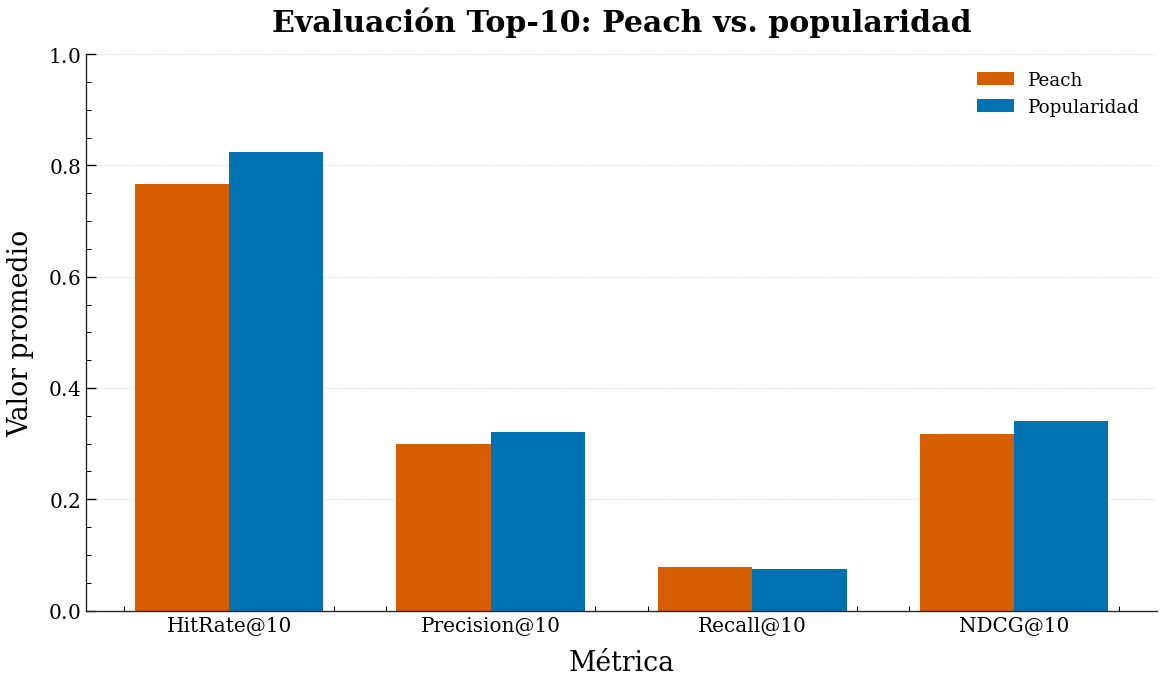

Gráfica guardada: 02_peach_vs_popularidad.png y 02_peach_vs_popularidad.pdf


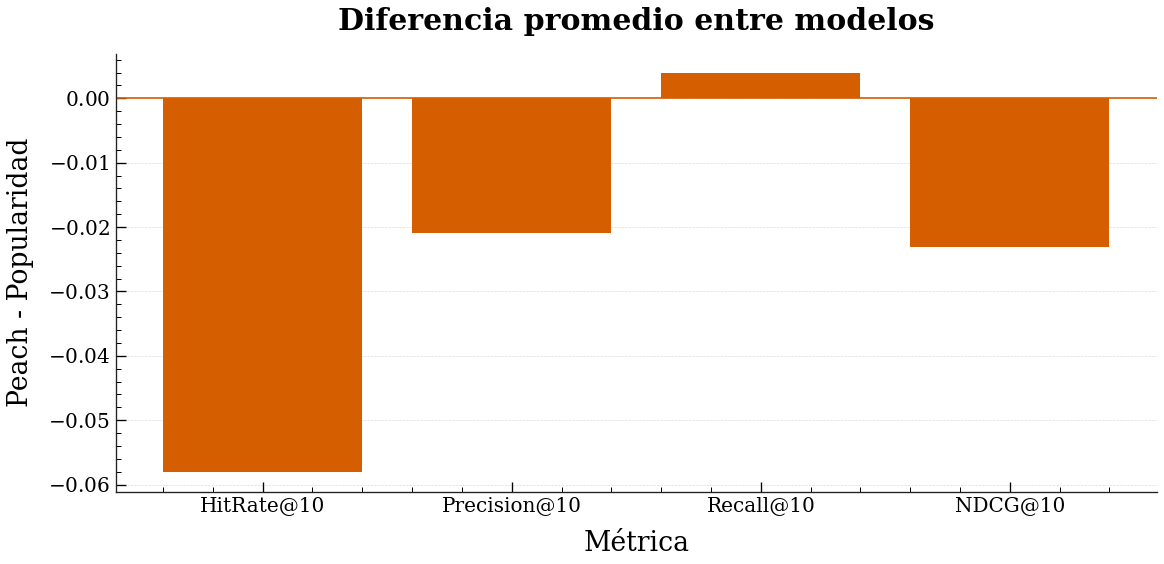

Gráfica guardada: 03_diferencia_peach_popularidad.png y 03_diferencia_peach_popularidad.pdf


PosixPath('/content/graficas_peach_final/03_diferencia_peach_popularidad.png')

In [74]:
# ============================================================
# GRÁFICA COMPARATIVA
# ============================================================

metric_labels = (
    metrics_summary[
        "Métrica"
    ].tolist()
)

peach_means = (
    metrics_summary[
        "Peach"
    ].to_numpy()
)

popularity_means = (
    metrics_summary[
        "Popularidad"
    ].to_numpy()
)

x_positions = np.arange(
    len(metric_labels)
)

bar_width = 0.36

plt.figure(figsize=(10, 6))

plt.bar(
    x_positions
    - bar_width / 2,
    peach_means,
    width=bar_width,
    label="Peach"
)

plt.bar(
    x_positions
    + bar_width / 2,
    popularity_means,
    width=bar_width,
    label="Popularidad"
)

plt.xticks(
    x_positions,
    metric_labels
)

plt.ylim(0, 1)

plt.xlabel("Métrica")
plt.ylabel("Valor promedio")

plt.title(
    "Evaluación Top-10: Peach vs. popularidad"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
guardar_y_mostrar(
    "02_peach_vs_popularidad"
)


# ============================================================
# DIFERENCIAS EMPAREJADAS
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    metrics_summary[
        "Métrica"
    ],
    metrics_summary[
        "Diferencia"
    ]
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Métrica")
plt.ylabel(
    "Peach - Popularidad"
)

plt.title(
    "Diferencia promedio entre modelos"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
guardar_y_mostrar(
    "03_diferencia_peach_popularidad"
)

## 14. Cobertura de las recomendaciones

Además de la precisión, se analiza cuántas películas diferentes recomienda cada modelo.

La cobertura de catálogo se define como:

$$
\operatorname{Coverage}
=
\frac{
\text{películas únicas recomendadas}
}{
\text{películas disponibles en el catálogo}
}.
$$

Esta medida permite observar si un modelo concentra sus recomendaciones en unas pocas películas populares o si explora una parte más amplia del catálogo.

In [75]:
# ============================================================
# COBERTURA DEL CATÁLOGO
# ============================================================

unique_peach_recommendations = set()

for recommendations in evaluation_results[
    "peach_recommendations"
]:
    unique_peach_recommendations.update(
        int(movie_id)
        for movie_id
        in recommendations
    )

unique_popularity_recommendations = set()

for recommendations in evaluation_results[
    "popularity_recommendations"
]:
    unique_popularity_recommendations.update(
        int(movie_id)
        for movie_id
        in recommendations
    )

catalog_size = len(
    model_movie_ids
)

coverage_summary = pd.DataFrame({
    "Modelo": [
        "Peach",
        "Popularidad"
    ],
    "Películas únicas recomendadas": [
        len(
            unique_peach_recommendations
        ),
        len(
            unique_popularity_recommendations
        )
    ],
    "Cobertura del catálogo": [
        len(
            unique_peach_recommendations
        )
        / catalog_size,

        len(
            unique_popularity_recommendations
        )
        / catalog_size
    ]
})

display(
    coverage_summary.round(6)
)

,Modelo,Películas únicas recomendadas,Cobertura del catálogo
0,Peach,672,0.008680
1,Popularidad,13,0.000168


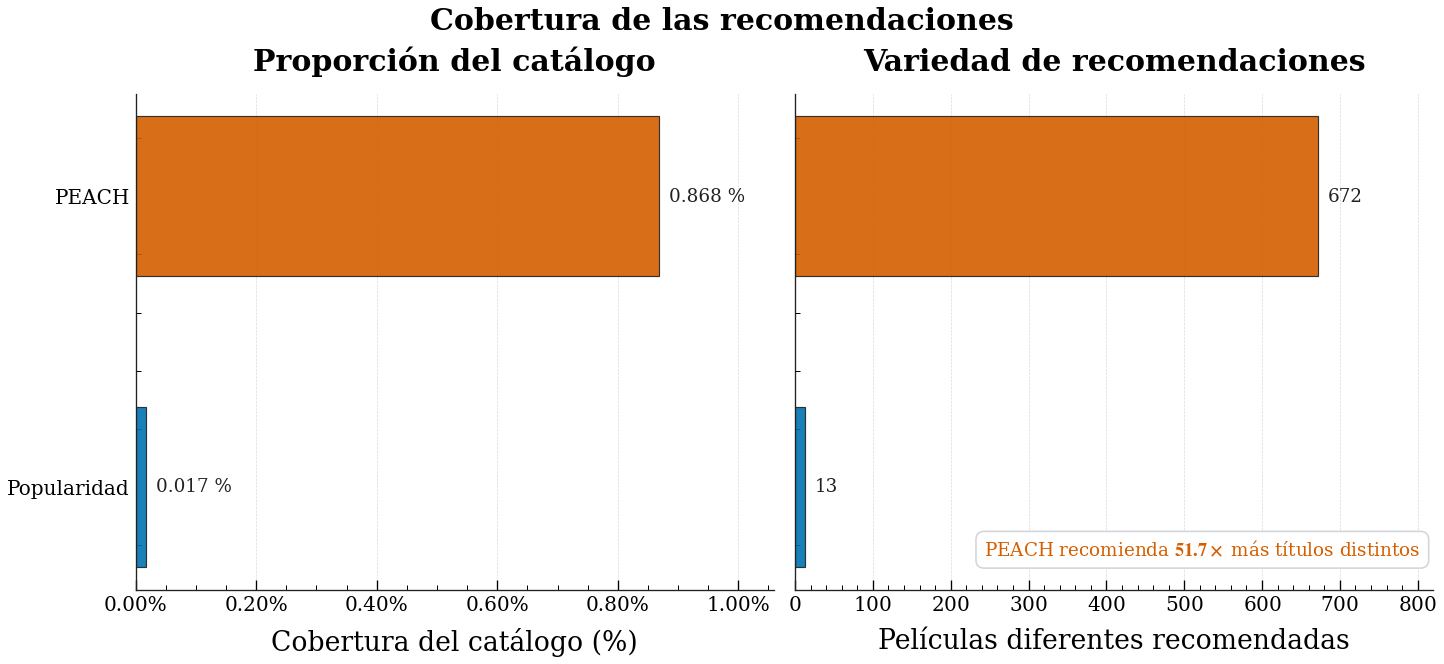

Gráfica guardada: 04_cobertura_peach_vs_popularidad.png y 04_cobertura_peach_vs_popularidad.pdf


PosixPath('/content/graficas_peach_final/04_cobertura_peach_vs_popularidad.png')

In [76]:
# ============================================================
# COBERTURA DEL CATÁLOGO
# Comparación mediante barras horizontales
# ============================================================

coverage_plot = (
    coverage_summary
    .copy()
)

coverage_plot[
    "Modelo"
] = (
    coverage_plot[
        "Modelo"
    ]
    .str.replace(
        "Peach",
        "PEACH",
        regex=False
    )
)

coverage_plot[
    "Cobertura porcentual"
] = (
    100.0
    * coverage_plot[
        "Cobertura del catálogo"
    ]
)

# Mantener un orden fijo y fácil de interpretar.
model_order = [
    "PEACH",
    "Popularidad"
]

coverage_plot = (
    coverage_plot
    .set_index("Modelo")
    .loc[model_order]
    .reset_index()
)

model_labels = (
    coverage_plot[
        "Modelo"
    ].tolist()
)

coverage_values = (
    coverage_plot[
        "Cobertura porcentual"
    ].to_numpy(
        dtype=np.float64
    )
)

unique_values = (
    coverage_plot[
        "Películas únicas recomendadas"
    ].to_numpy(
        dtype=np.int64
    )
)

bar_colors = [
    PEACH_ORANGE,
    POPULARITY_BLUE
]

y_positions = np.arange(
    len(model_labels)
)


# ============================================================
# Relaciones entre los resultados
# ============================================================

coverage_ratio = (
    coverage_values[0]
    / coverage_values[1]
)

unique_ratio = (
    unique_values[0]
    / unique_values[1]
)


# ============================================================
# FIGURA
# ============================================================

fig, (
    ax_coverage,
    ax_unique
) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5.5),
    sharey=True,
    layout="constrained"
)

fig.suptitle(
    "Cobertura de las recomendaciones",
    fontsize=18,
    fontweight="semibold"
)


# ============================================================
# PANEL 1: PORCENTAJE DEL CATÁLOGO
# ============================================================

coverage_bars = ax_coverage.barh(
    y_positions,
    coverage_values,
    color=bar_colors,
    edgecolor=PEACH_DARK,
    linewidth=0.7,
    alpha=0.90,
    height=0.55
)

ax_coverage.set_yticks(
    y_positions
)

ax_coverage.set_yticklabels(
    model_labels
)

ax_coverage.invert_yaxis()

ax_coverage.set_xlabel(
    "Cobertura del catálogo (%)"
)

ax_coverage.set_title(
    "Proporción del catálogo"
)

ax_coverage.set_xlim(
    0,
    1.22
    * coverage_values.max()
)

ax_coverage.xaxis.set_major_formatter(
    PercentFormatter(
        xmax=100,
        decimals=2
    )
)

for bar, value in zip(
    coverage_bars,
    coverage_values
):
    ax_coverage.annotate(
        f"{value:.3f} %",
        xy=(
            bar.get_width(),
            bar.get_y()
            + bar.get_height() / 2
        ),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11,
        color=PEACH_DARK
    )

aplicar_estilo_cientifico(
    ax_coverage,
    eje_cuadricula="x"
)

ax_coverage.tick_params(
    axis="y",
    length=0
)


# ============================================================
# PANEL 2: PELÍCULAS DIFERENTES
# ============================================================

unique_bars = ax_unique.barh(
    y_positions,
    unique_values,
    color=bar_colors,
    edgecolor=PEACH_DARK,
    linewidth=0.7,
    alpha=0.90,
    height=0.55
)

ax_unique.set_xlabel(
    "Películas diferentes recomendadas"
)

ax_unique.set_title(
    "Variedad de recomendaciones"
)

ax_unique.set_xlim(
    0,
    1.22
    * unique_values.max()
)

for bar, value in zip(
    unique_bars,
    unique_values
):
    ax_unique.annotate(
        f"{value:,}".replace(
            ",",
            " "
        ),
        xy=(
            bar.get_width(),
            bar.get_y()
            + bar.get_height() / 2
        ),
        xytext=(6, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=11,
        color=PEACH_DARK
    )

aplicar_estilo_cientifico(
    ax_unique,
    eje_cuadricula="x"
)

ax_unique.tick_params(
    axis="y",
    length=0
)


# ============================================================
# MENSAJE PRINCIPAL
# ============================================================

ax_unique.text(
    0.98,
    0.06,
    (
        rf"PEACH recomienda "
        rf"$\mathbf{{{unique_ratio:.1f}\times}}$ "
        "más títulos distintos"
    ),
    transform=ax_unique.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    color=PEACH_ORANGE,
    bbox={
        "facecolor": "white",
        "edgecolor": PEACH_LIGHT_GRAY,
        "boxstyle": "round,pad=0.45",
        "alpha": 0.95
    }
)


guardar_y_mostrar(
    "04_cobertura_peach_vs_popularidad"
)

## 15. Diagnóstico numérico y efecto de la regularización

Se estudian las propiedades numéricas de la aproximación SVD y de los sistemas utilizados para estimar usuarios nuevos.

Para cada componente singular se analiza:

- Magnitud del valor singular.
- Aporte individual de energía.
- Energía acumulada.
- Error relativo de reconstrucción.

La energía capturada por los primeros $k$ factores se define como:

$$
E_k
=
\frac{
\sum_{j=1}^{k}\sigma_j^2
}{
\left\|R_{\mathrm{train}}\right\|_F^2
}.
$$

El error relativo asociado se estima mediante:

$$
e_k
=
\sqrt{1-E_k}.
$$

También se compara el condicionamiento de los sistemas:

$$
Q_u^\top Q_u
$$

y

$$
Q_u^\top Q_u+\lambda I.
$$

Como cada usuario revela cinco ratings y el espacio latente tiene dimensión 50, el sistema sin regularización es deficiente en rango. La regularización permite obtener un sistema invertible y numéricamente más estable.

## 16. Sensibilidad respecto a la dimensión latente $k$

Se estudia cómo cambia el comportamiento del modelo al modificar la cantidad de factores latentes.

Se consideran dos conjuntos de valores para la dimensión latente.

Para estudiar la calidad de las recomendaciones, la cobertura y el costo por usuario se utilizan:

$$
k\in\{10,20,30,50,75,100\}.
$$

Para medir específicamente el costo temporal del cálculo de la SVD truncada se utilizan:

$$
k\in\{10,20,50,100,200\}.
$$

El valor $k=200$ se emplea únicamente en el experimento de tiempo de entrenamiento. No se utiliza para evaluar las métricas de recomendación, con el propósito de controlar el costo computacional.

Se analiza:

- Tiempo necesario para calcular la SVD.
- Energía capturada.
- Error relativo de reconstrucción.
- HitRate@10.
- Precision@10.
- Recall@10.
- NDCG@10.
- Cobertura del catálogo.
- Tiempo promedio de evaluación por usuario.

La comparación de métricas utiliza siempre los mismos usuarios y los mismos cinco ratings observados.

,Medida,Valor
0,Energía capturada,0.418113
1,Error relativo estimado,0.762815
2,Valor singular máximo,7547.227051
3,Valor singular mínimo conservado,629.360413
4,Razón sigma_max / sigma_min,11.991900


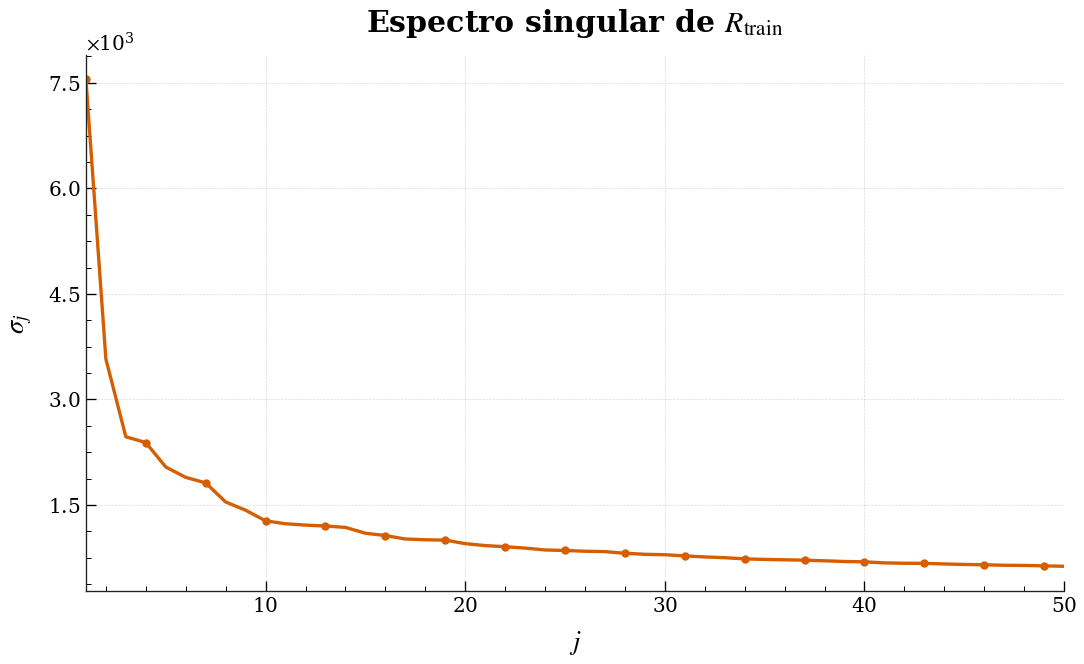

Gráfica guardada: 05_espectro_singular.png y 05_espectro_singular.pdf


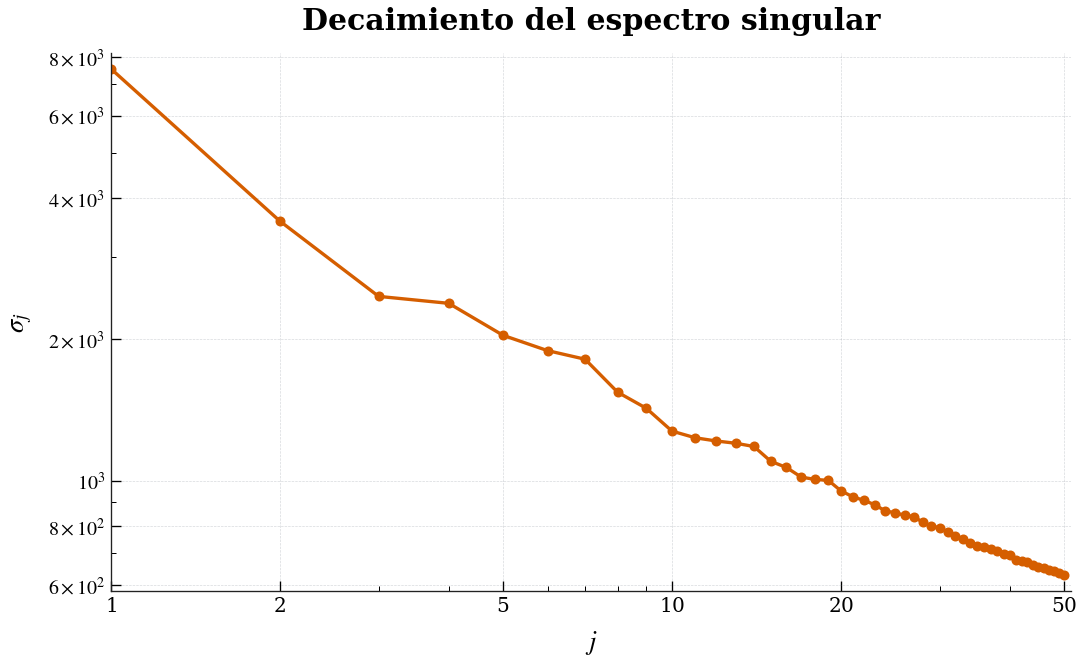

Gráfica guardada: 06_espectro_singular_logaritmico.png y 06_espectro_singular_logaritmico.pdf


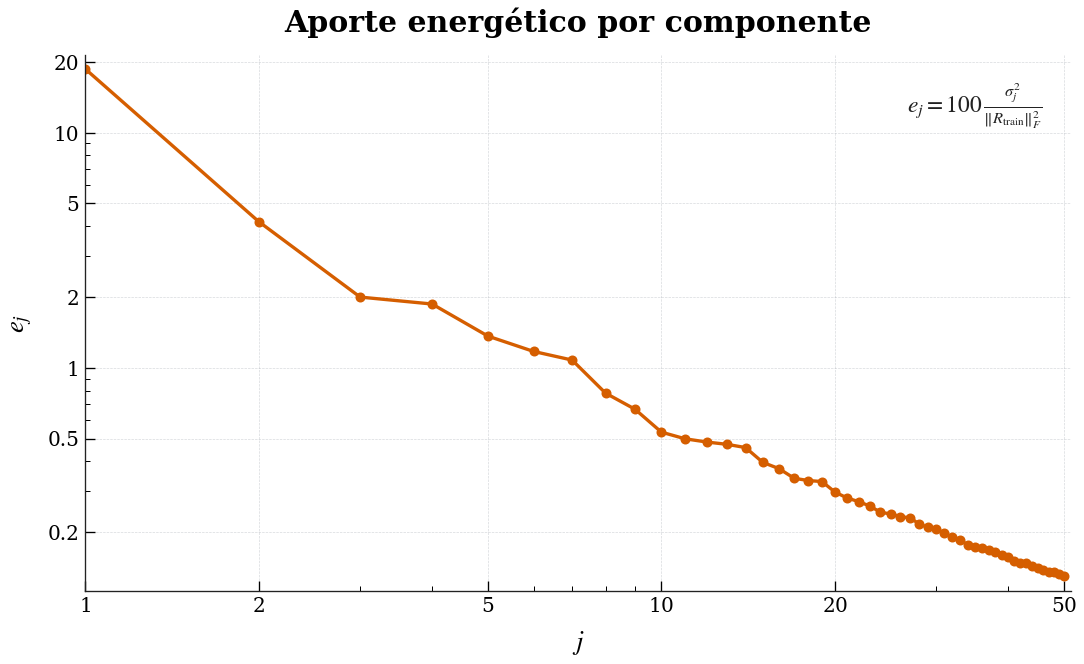

Gráfica guardada: 07_aporte_individual_energia.png y 07_aporte_individual_energia.pdf


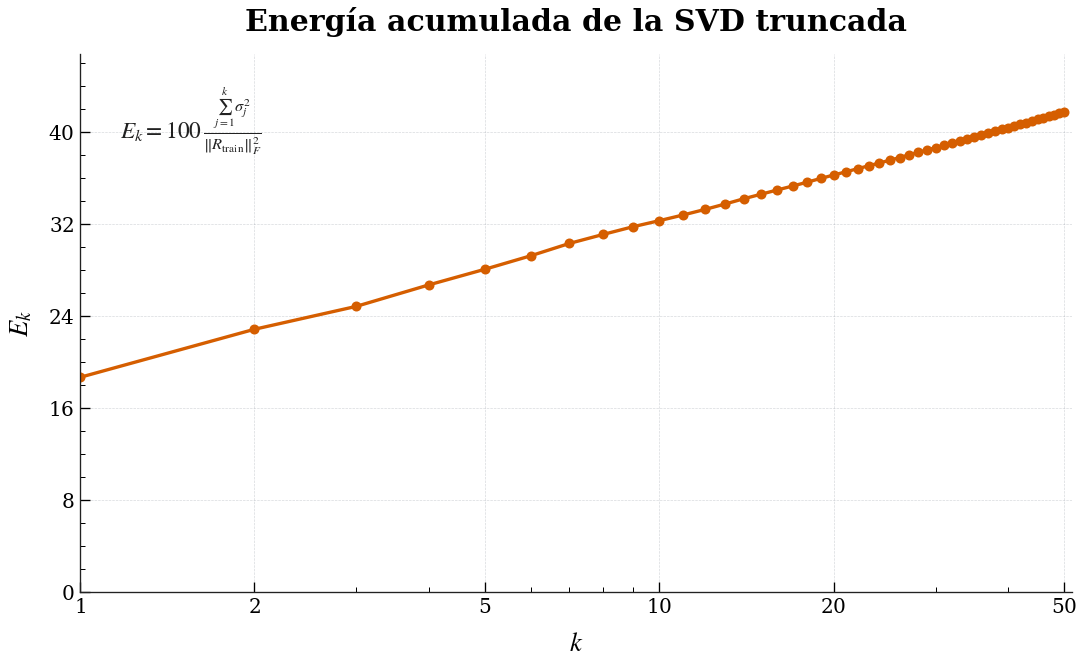

Gráfica guardada: 08_energia_acumulada.png y 08_energia_acumulada.pdf


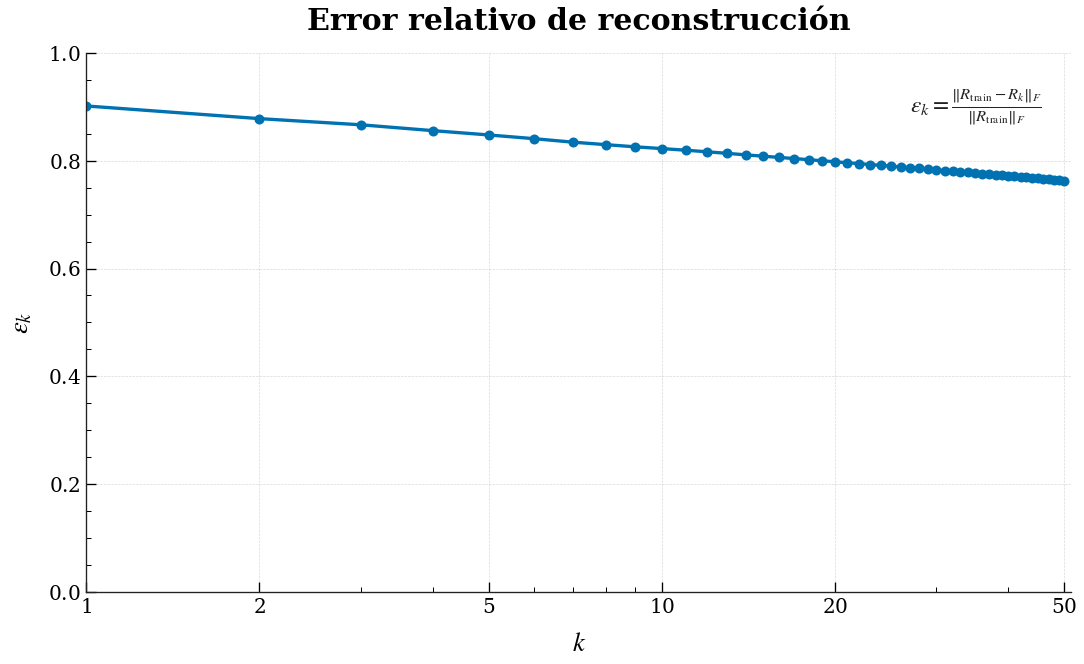

Gráfica guardada: 09_error_relativo_reconstruccion.png y 09_error_relativo_reconstruccion.pdf
Usuarios analizados: 100
Valores no finitos sin regularización: 0
Valores no finitos con regularización: 0


,condition_without_regularization,condition_with_regularization
count,1.000000e+02,1.000000e+02
mean,4.195468e+20,6.162935e+06
std,1.823877e+21,4.875871e+06
min,1.633215e+19,4.604814e+03
25%,5.680064e+19,2.644932e+06
50%,1.143024e+20,4.850934e+06
75%,2.266993e+20,8.543523e+06
max,1.717911e+22,2.261114e+07


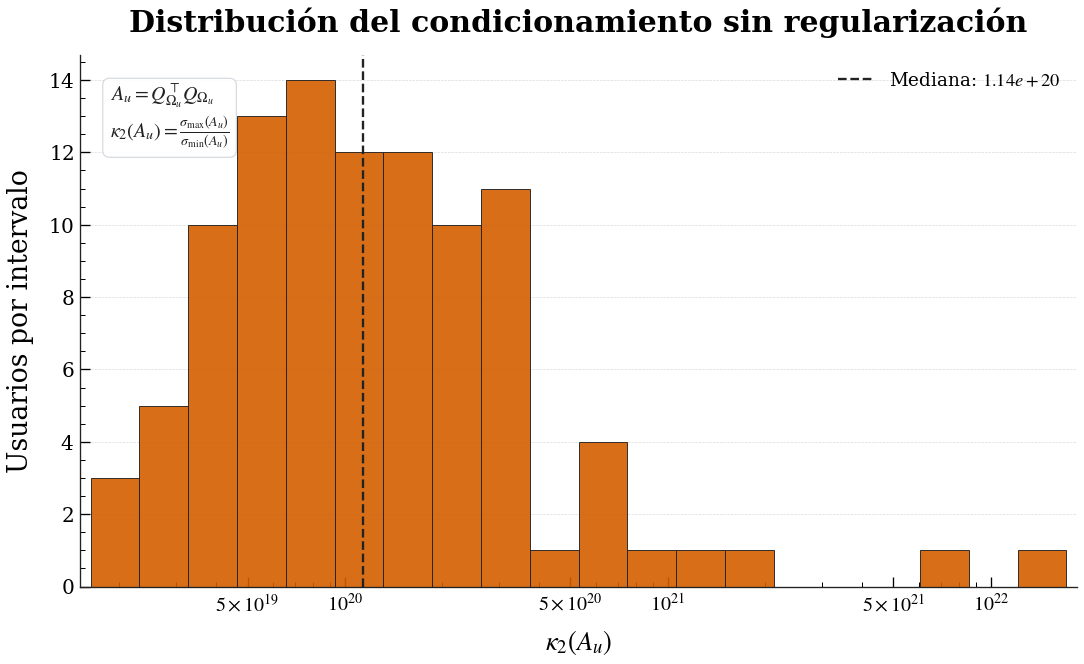

Gráfica guardada: 10_condicionamiento_sin_regularizacion.png y 10_condicionamiento_sin_regularizacion.pdf


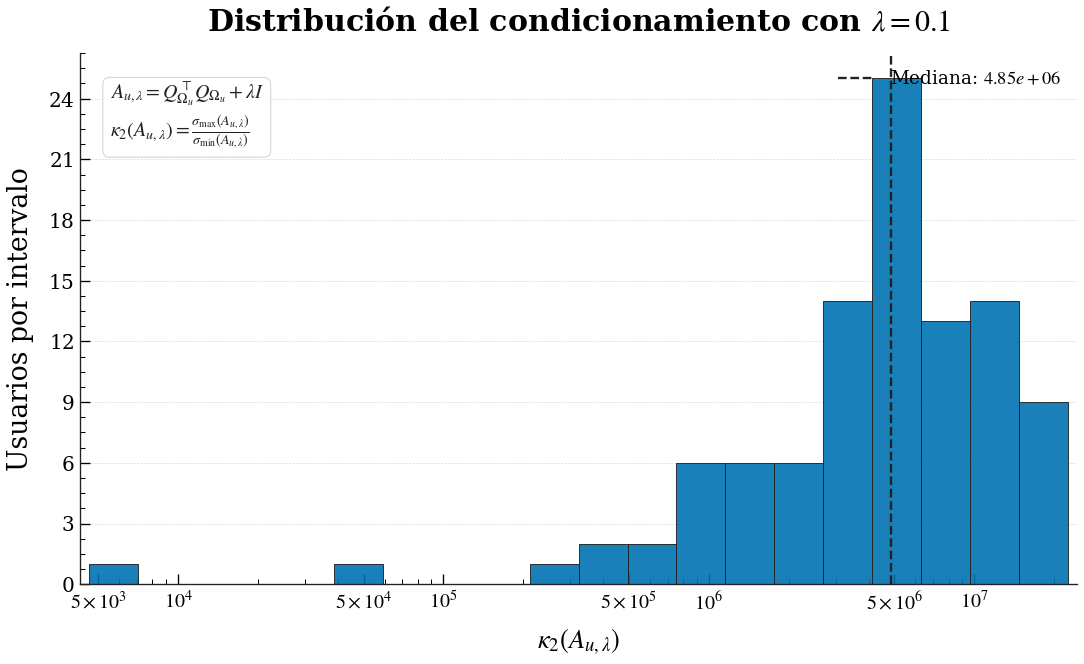

Gráfica guardada: 11_condicionamiento_con_regularizacion.png y 11_condicionamiento_con_regularizacion.pdf


,lambda,median_condition,mean_condition
0,0.000001,4.850990e+11,6.163111e+11
1,0.000100,4.850934e+09,6.162936e+09
2,0.001000,4.850933e+08,6.162934e+08
3,0.010000,4.850933e+07,6.162934e+07
4,0.100000,4.850934e+06,6.162935e+06
5,1.000000,4.850943e+05,6.162944e+05


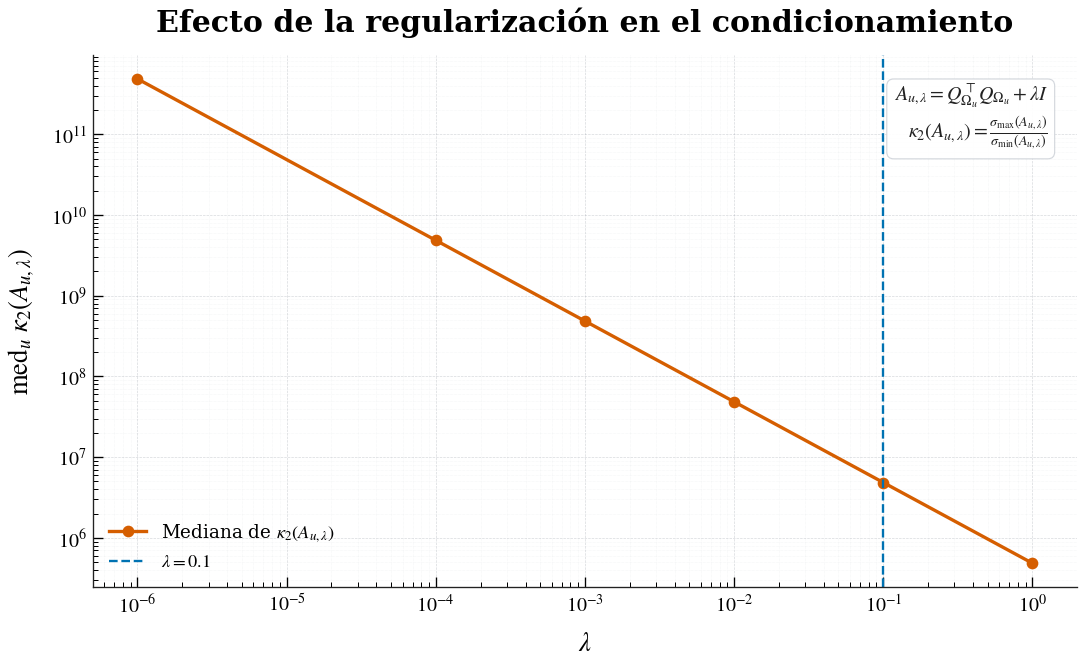

Gráfica guardada: 12_condicionamiento_segun_lambda.png y 12_condicionamiento_segun_lambda.pdf


PosixPath('/content/graficas_peach_final/12_condicionamiento_segun_lambda.png')

In [77]:
# ============================================================
# ENERGÍA, ERROR Y CONDICIONAMIENTO NUMÉRICO
# ============================================================

from matplotlib.ticker import (
    ScalarFormatter,
    LogLocator,
    NullFormatter,
    FixedLocator,
    FuncFormatter,
    MaxNLocator
)


# ============================================================
# FUNCIONES AUXILIARES PARA LOS EJES
# ============================================================

def obtener_ticks_componentes(maximum_component):
    """
    Selecciona marcas legibles para índices j o dimensiones k
    representados mediante un eje logarítmico.
    """

    candidate_ticks = np.array(
        [
            1,
            2,
            5,
            10,
            20,
            50,
            100,
            200,
            500,
            1000
        ],
        dtype=np.int64
    )

    valid_ticks = candidate_ticks[
        candidate_ticks <= int(maximum_component)
    ]

    if valid_ticks.size == 0:
        return [1]

    return valid_ticks.tolist()


def configurar_log_x_componentes(
    ax,
    maximum_component
):
    """
    Configura un eje logarítmico para j o k mostrando
    únicamente valores enteros relevantes.
    """

    ticks = obtener_ticks_componentes(
        maximum_component
    )

    ax.set_xscale(
        "log"
    )

    ax.set_xlim(
        1,
        maximum_component * 1.03
    )

    ax.set_xticks(
        ticks
    )

    formatter = ScalarFormatter()

    formatter.set_scientific(
        False
    )

    formatter.set_useOffset(
        False
    )

    ax.xaxis.set_major_formatter(
        formatter
    )

    ax.xaxis.set_minor_locator(
        LogLocator(
            base=10,
            subs=np.arange(
                2,
                10
            ),
            numticks=100
        )
    )

    ax.xaxis.set_minor_formatter(
        NullFormatter()
    )


def formatear_tick_cientifico(
    value,
    position=None
):
    """
    Escribe las marcas logarítmicas como:

    10^3
    2 × 10^3
    5 × 10^3
    """

    if (
        not np.isfinite(value)
        or value <= 0
    ):
        return ""

    exponent = int(
        np.floor(
            np.log10(value)
        )
    )

    mantissa = (
        value
        / (
            10.0 ** exponent
        )
    )

    if np.isclose(
        mantissa,
        1.0
    ):
        return rf"$10^{{{exponent}}}$"

    if np.isclose(
        mantissa,
        round(mantissa)
    ):
        mantissa_text = str(
            int(
                round(mantissa)
            )
        )

    else:
        mantissa_text = (
            f"{mantissa:.1f}"
        )

    return (
        rf"${mantissa_text}"
        rf"\times 10^{{{exponent}}}$"
    )


def formatear_tick_decimal_log(
    value,
    position=None
):
    """
    Escribe marcas de un eje logarítmico mediante valores
    decimales simples:

    0.1, 0.2, 0.5, 1, 2, 5, 10
    """

    if (
        not np.isfinite(value)
        or value <= 0
    ):
        return ""

    if value >= 1:
        if np.isclose(
            value,
            round(value)
        ):
            return str(
                int(
                    round(value)
                )
            )

        return f"{value:g}"

    if value >= 0.1:
        return f"{value:.1f}"

    if value >= 0.01:
        return f"{value:.2f}"

    return f"{value:g}"


def construir_ticks_logaritmicos(
    values,
    mantissas,
    margin_factor=1.10
):
    """
    Construye marcas logarítmicas dentro del rango observado.

    Los ticks siguen las mantisas solicitadas en cada década.
    """

    values = np.asarray(
        values,
        dtype=np.float64
    )

    positive_values = values[
        np.isfinite(values)
        & (values > 0)
    ]

    if positive_values.size == 0:
        raise ValueError(
            "No existen valores positivos para el eje logarítmico."
        )

    minimum_value = float(
        positive_values.min()
    )

    maximum_value = float(
        positive_values.max()
    )

    minimum_exponent = int(
        np.floor(
            np.log10(minimum_value)
        )
    )

    maximum_exponent = int(
        np.floor(
            np.log10(maximum_value)
        )
    )

    candidate_ticks = []

    for exponent in range(
        minimum_exponent - 1,
        maximum_exponent + 2
    ):
        for mantissa in mantissas:
            candidate_ticks.append(
                float(mantissa)
                * (
                    10.0 ** exponent
                )
            )

    candidate_ticks = np.asarray(
        candidate_ticks,
        dtype=np.float64
    )

    lower_limit = (
        minimum_value
        / margin_factor
    )

    upper_limit = (
        maximum_value
        * margin_factor
    )

    ticks = candidate_ticks[
        (candidate_ticks >= lower_limit)
        & (candidate_ticks <= upper_limit)
    ]

    return np.unique(
        ticks
    )


def configurar_log_y_espectro(
    ax,
    values
):
    """
    Configura el eje y del espectro con marcas estructuradas:

    6×10², 8×10², 10³, 2×10³, 4×10³, ...
    """

    values = np.asarray(
        values,
        dtype=np.float64
    )

    positive_values = values[
        np.isfinite(values)
        & (values > 0)
    ]

    if positive_values.size == 0:
        raise ValueError(
            "No existen valores positivos para el espectro."
        )

    minimum_value = float(
        positive_values.min()
    )

    maximum_value = float(
        positive_values.max()
    )

    major_ticks = construir_ticks_logaritmicos(
        positive_values,
        mantissas=(
            1,
            2,
            4,
            6,
            8
        ),
        margin_factor=1.10
    )

    ax.set_yscale(
        "log"
    )

    ax.set_ylim(
        minimum_value / 1.08,
        maximum_value * 1.08
    )

    ax.yaxis.set_major_locator(
        FixedLocator(
            major_ticks
        )
    )

    ax.yaxis.set_major_formatter(
        FuncFormatter(
            formatear_tick_cientifico
        )
    )

    ax.yaxis.set_minor_locator(
        LogLocator(
            base=10,
            subs=(
                3,
                5,
                7,
                9
            ),
            numticks=100
        )
    )

    ax.yaxis.set_minor_formatter(
        NullFormatter()
    )


def configurar_log_y_energia(
    ax,
    values
):
    """
    Configura el aporte energético usando la sucesión
    logarítmica estándar 1–2–5 por década.
    """

    values = np.asarray(
        values,
        dtype=np.float64
    )

    positive_values = values[
        np.isfinite(values)
        & (values > 0)
    ]

    if positive_values.size == 0:
        raise ValueError(
            "No existen aportes energéticos positivos."
        )

    minimum_value = float(
        positive_values.min()
    )

    maximum_value = float(
        positive_values.max()
    )

    major_ticks = construir_ticks_logaritmicos(
        positive_values,
        mantissas=(
            1,
            2,
            5
        ),
        margin_factor=1.25
    )

    ax.set_yscale(
        "log"
    )

    ax.set_ylim(
        minimum_value / 1.15,
        maximum_value * 1.15
    )

    ax.yaxis.set_major_locator(
        FixedLocator(
            major_ticks
        )
    )

    ax.yaxis.set_major_formatter(
        FuncFormatter(
            formatear_tick_decimal_log
        )
    )

    ax.yaxis.set_minor_locator(
        LogLocator(
            base=10,
            subs=(
                3,
                4,
                6,
                7,
                8,
                9
            ),
            numticks=100
        )
    )

    ax.yaxis.set_minor_formatter(
        NullFormatter()
    )


def configurar_log_x_histograma(
    ax,
    values
):
    """
    Configura el eje x de los histogramas mostrando dos
    referencias por década:

    10^n y 5 × 10^n.
    """

    values = np.asarray(
        values,
        dtype=np.float64
    )

    positive_values = values[
        np.isfinite(values)
        & (values > 0)
    ]

    if positive_values.size == 0:
        raise ValueError(
            "No existen números de condición positivos."
        )

    minimum_value = float(
        positive_values.min()
    )

    maximum_value = float(
        positive_values.max()
    )

    major_ticks = construir_ticks_logaritmicos(
        positive_values,
        mantissas=(
            1,
            5
        ),
        margin_factor=1.10
    )

    ax.set_xscale(
        "log"
    )

    ax.set_xlim(
        minimum_value / 1.08,
        maximum_value * 1.08
    )

    ax.xaxis.set_major_locator(
        FixedLocator(
            major_ticks
        )
    )

    ax.xaxis.set_major_formatter(
        FuncFormatter(
            formatear_tick_cientifico
        )
    )

    ax.xaxis.set_minor_locator(
        LogLocator(
            base=10,
            subs=(
                2,
                3,
                4,
                6,
                7,
                8,
                9
            ),
            numticks=100
        )
    )

    ax.xaxis.set_minor_formatter(
        NullFormatter()
    )


def configurar_log_por_decadas(
    ax,
    axis="x"
):
    """
    Configura un eje logarítmico mostrando únicamente
    potencias de diez como marcas principales.
    """

    major_locator = LogLocator(
        base=10,
        subs=(1.0,),
        numticks=30
    )

    minor_locator = LogLocator(
        base=10,
        subs=np.arange(
            2,
            10
        ),
        numticks=100
    )

    formatter = FuncFormatter(
        formatear_tick_cientifico
    )

    if axis == "x":
        ax.set_xscale(
            "log"
        )

        ax.xaxis.set_major_locator(
            major_locator
        )

        ax.xaxis.set_major_formatter(
            formatter
        )

        ax.xaxis.set_minor_locator(
            minor_locator
        )

        ax.xaxis.set_minor_formatter(
            NullFormatter()
        )

    elif axis == "y":
        ax.set_yscale(
            "log"
        )

        ax.yaxis.set_major_locator(
            major_locator
        )

        ax.yaxis.set_major_formatter(
            formatter
        )

        ax.yaxis.set_minor_locator(
            minor_locator
        )

        ax.yaxis.set_minor_formatter(
            NullFormatter()
        )

    else:
        raise ValueError(
            "axis debe ser 'x' o 'y'."
        )


def construir_bins_logaritmicos(
    values,
    n_bins=20
):
    """
    Construye intervalos geométricos para histogramas con
    eje horizontal logarítmico.
    """

    values = np.asarray(
        values,
        dtype=np.float64
    )

    positive_values = values[
        np.isfinite(values)
        & (values > 0)
    ]

    if positive_values.size == 0:
        raise ValueError(
            "No existen valores positivos y finitos."
        )

    minimum_value = float(
        positive_values.min()
    )

    maximum_value = float(
        positive_values.max()
    )

    if np.isclose(
        minimum_value,
        maximum_value
    ):
        minimum_value /= 1.10
        maximum_value *= 1.10

    return np.geomspace(
        minimum_value,
        maximum_value,
        n_bins + 1
    )


# ============================================================
# ENERGÍA Y ERROR DE RECONSTRUCCIÓN
# ============================================================

rating_values_float64 = (
    R_train.data.astype(
        np.float64
    )
)

frobenius_squared = float(
    np.dot(
        rating_values_float64,
        rating_values_float64
    )
)

if (
    not np.isfinite(
        frobenius_squared
    )
    or frobenius_squared <= 0
):
    raise ValueError(
        "La norma de Frobenius de R_train no es válida."
    )


singular_values = np.asarray(
    S,
    dtype=np.float64
).reshape(-1)

if singular_values.size == 0:
    raise ValueError(
        "No existen valores singulares."
    )

if not np.all(
    np.isfinite(
        singular_values
    )
):
    raise ValueError(
        "Los valores singulares contienen NaN o infinito."
    )

# El espectro se representa en orden decreciente.
singular_values = np.sort(
    singular_values
)[::-1]

singular_squared = (
    singular_values ** 2
)

component_indices = np.arange(
    1,
    singular_values.size + 1,
    dtype=np.int64
)

individual_energy = (
    singular_squared
    / frobenius_squared
)

cumulative_energy = (
    np.cumsum(
        singular_squared
    )
    / frobenius_squared
)

cumulative_energy = np.clip(
    cumulative_energy,
    0.0,
    1.0
)

relative_error_curve = np.sqrt(
    np.maximum(
        0.0,
        1.0 - cumulative_energy
    )
)

captured_energy = float(
    cumulative_energy[-1]
)

relative_reconstruction_error = float(
    relative_error_curve[-1]
)

if singular_values[-1] > 0:
    singular_value_ratio = float(
        singular_values[0]
        / singular_values[-1]
    )

else:
    singular_value_ratio = np.inf


# ============================================================
# RESUMEN NUMÉRICO
# ============================================================

numerical_summary = pd.DataFrame({
    "Medida": [
        "Energía capturada",
        "Error relativo estimado",
        "Valor singular máximo",
        "Valor singular mínimo conservado",
        "Razón sigma_max / sigma_min"
    ],
    "Valor": [
        captured_energy,
        relative_reconstruction_error,
        float(
            singular_values[0]
        ),
        float(
            singular_values[-1]
        ),
        singular_value_ratio
    ]
})

display(
    numerical_summary
)


# ============================================================
# GRÁFICA 1: ESPECTRO SINGULAR
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained"
)

ax.plot(
    component_indices,
    singular_values,
    color=PEACH_ORANGE,
    marker="o",
    markersize=4,
    markevery=max(
        1,
        component_indices.size // 15
    ),
    linewidth=2.0
)

ax.set_xlabel(
    r"$j$"
)

ax.set_ylabel(
    r"$\sigma_j$"
)

ax.set_title(
    r"Espectro singular de $R_{\mathrm{train}}$"
)

ax.set_xlim(
    component_indices.min(),
    component_indices.max()
)

ax.ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(0, 0),
    useMathText=True
)

ax.yaxis.set_major_locator(
    MaxNLocator(
        nbins=6
    )
)

aplicar_estilo_cientifico(
    ax
)

guardar_y_mostrar(
    "05_espectro_singular"
)


# ============================================================
# GRÁFICA 2: DECAIMIENTO DEL ESPECTRO SINGULAR
# ESCALA LOG-LOG
# ============================================================

singular_mask = (
    np.isfinite(
        singular_values
    )
    & (
        singular_values > 0
    )
)

if not np.any(
    singular_mask
):
    raise ValueError(
        "No existen valores singulares positivos."
    )

j_plot = component_indices[
    singular_mask
]

sigma_plot = singular_values[
    singular_mask
]


fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained"
)

ax.plot(
    j_plot,
    sigma_plot,
    color=PEACH_ORANGE,
    marker="o",
    markersize=5,
    linewidth=2.0
)

configurar_log_x_componentes(
    ax,
    component_indices.max()
)

configurar_log_y_espectro(
    ax,
    sigma_plot
)

ax.set_xlabel(
    r"$j$"
)

ax.set_ylabel(
    r"$\sigma_j$"
)

ax.set_title(
    "Decaimiento del espectro singular"
)

aplicar_estilo_cientifico(
    ax,
    eje_cuadricula="both"
)

guardar_y_mostrar(
    "06_espectro_singular_logaritmico"
)


# ============================================================
# GRÁFICA 3: APORTE ENERGÉTICO INDIVIDUAL
# ============================================================

individual_energy_percent = (
    100.0
    * individual_energy
)

energy_mask = (
    np.isfinite(
        individual_energy_percent
    )
    & (
        individual_energy_percent > 0
    )
)

if not np.any(
    energy_mask
):
    raise ValueError(
        "No existen aportes energéticos positivos."
    )

j_energy_plot = component_indices[
    energy_mask
]

energy_plot = individual_energy_percent[
    energy_mask
]


fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained"
)

ax.plot(
    j_energy_plot,
    energy_plot,
    color=PEACH_ORANGE,
    marker="o",
    markersize=5,
    linewidth=2.0
)

configurar_log_x_componentes(
    ax,
    component_indices.max()
)

configurar_log_y_energia(
    ax,
    energy_plot
)

ax.set_xlabel(
    r"$j$"
)

ax.set_ylabel(
    r"$e_j$"
)

ax.set_title(
    "Aporte energético por componente"
)

ax.text(
    0.97,
    0.95,
    (
        r"$e_j="
        r"100\,"
        r"\frac{\sigma_j^2}"
        r"{\Vert R_{\mathrm{train}}\Vert_F^2}$"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=14,
    color=PEACH_DARK
)

aplicar_estilo_cientifico(
    ax,
    eje_cuadricula="both"
)

guardar_y_mostrar(
    "07_aporte_individual_energia"
)


# ============================================================
# GRÁFICA 4: ENERGÍA ACUMULADA
# ============================================================

cumulative_energy_percent = (
    100.0
    * cumulative_energy
)

fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained"
)

ax.plot(
    component_indices,
    cumulative_energy_percent,
    color=PEACH_ORANGE,
    marker="o",
    markersize=5,
    linewidth=2.0
)

configurar_log_x_componentes(
    ax,
    component_indices.max()
)

ax.set_xlabel(
    r"$k$"
)

ax.set_ylabel(
    r"$E_k$"
)

ax.set_title(
    "Energía acumulada de la SVD truncada"
)

maximum_energy_percent = float(
    cumulative_energy_percent.max()
)

ax.set_ylim(
    0,
    min(
        100.0,
        maximum_energy_percent + 5.0
    )
)

ax.yaxis.set_major_locator(
    MaxNLocator(
        nbins=6
    )
)

ax.text(
    0.04,
    0.94,
    (
        r"$E_k="
        r"100\,"
        r"\frac{\sum_{j=1}^{k}\sigma_j^2}"
        r"{\Vert R_{\mathrm{train}}\Vert_F^2}$"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=14,
    color=PEACH_DARK
)

aplicar_estilo_cientifico(
    ax
)

guardar_y_mostrar(
    "08_energia_acumulada"
)


# ============================================================
# GRÁFICA 5: ERROR RELATIVO DE RECONSTRUCCIÓN
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained"
)

ax.plot(
    component_indices,
    relative_error_curve,
    color=POPULARITY_BLUE,
    marker="o",
    markersize=5,
    linewidth=2.0
)

configurar_log_x_componentes(
    ax,
    component_indices.max()
)

ax.set_xlabel(
    r"$k$"
)

ax.set_ylabel(
    r"$\varepsilon_k$"
)

ax.set_title(
    "Error relativo de reconstrucción"
)

ax.set_ylim(
    0,
    1
)

ax.yaxis.set_major_locator(
    MaxNLocator(
        nbins=6
    )
)

ax.text(
    0.97,
    0.94,
    (
        r"$\varepsilon_k="
        r"\frac{\Vert R_{\mathrm{train}}-R_k\Vert_F}"
        r"{\Vert R_{\mathrm{train}}\Vert_F}$"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=14,
    color=PEACH_DARK
)

aplicar_estilo_cientifico(
    ax
)

guardar_y_mostrar(
    "09_error_relativo_reconstruccion"
)


# ============================================================
# CONDICIONAMIENTO DE USUARIOS NUEVOS
# ============================================================

condition_user_count = min(
    N_CONDITION_USERS,
    len(selected_test_user_ids)
)

condition_user_ids = selected_test_user_ids[
    :condition_user_count
]

condition_rows = []

identity_matrix = np.eye(
    Q.shape[1],
    dtype=np.float64
)

for user_id in condition_user_ids:
    user_id = int(
        user_id
    )

    user_split = (
        prepare_test_user_history(
            user_id=user_id,
            user_history=(
                evaluation_histories[
                    user_id
                ]
            )
        )
    )

    observed_columns = np.array(
        [
            movie_id_to_col[
                int(movie_id)
            ]
            for movie_id
            in user_split[
                "observed_movie_ids"
            ]
        ],
        dtype=np.int64
    )

    Q_observed = np.asarray(
        Q[
            observed_columns
        ],
        dtype=np.float64
    )

    gram_matrix = (
        Q_observed.T
        @ Q_observed
    )

    try:
        unregularized_condition = float(
            np.linalg.cond(
                gram_matrix
            )
        )

    except np.linalg.LinAlgError:
        unregularized_condition = np.inf

    try:
        regularized_condition = float(
            np.linalg.cond(
                gram_matrix
                + LAMBDA_REG
                * identity_matrix
            )
        )

    except np.linalg.LinAlgError:
        regularized_condition = np.inf

    condition_rows.append({
        "userId": user_id,
        "condition_without_regularization": (
            unregularized_condition
        ),
        "condition_with_regularization": (
            regularized_condition
        )
    })


condition_results = pd.DataFrame(
    condition_rows
)

if condition_results.empty:
    raise RuntimeError(
        "No se obtuvieron resultados de condicionamiento."
    )


# ============================================================
# RESUMEN DEL CONDICIONAMIENTO
# ============================================================

unregularized_conditions = (
    condition_results[
        "condition_without_regularization"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

regularized_conditions = (
    condition_results[
        "condition_with_regularization"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

finite_unregularized = unregularized_conditions[
    np.isfinite(
        unregularized_conditions
    )
    & (
        unregularized_conditions > 0
    )
]

finite_regularized = regularized_conditions[
    np.isfinite(
        regularized_conditions
    )
    & (
        regularized_conditions > 0
    )
]

nonfinite_unregularized_count = int(
    unregularized_conditions.size
    - finite_unregularized.size
)

nonfinite_regularized_count = int(
    regularized_conditions.size
    - finite_regularized.size
)

print(
    "Usuarios analizados:",
    len(condition_results)
)

print(
    "Valores no finitos sin regularización:",
    nonfinite_unregularized_count
)

print(
    "Valores no finitos con regularización:",
    nonfinite_regularized_count
)

display(
    condition_results[
        [
            "condition_without_regularization",
            "condition_with_regularization"
        ]
    ].describe()
)


# ============================================================
# GRÁFICA 6: CONDICIONAMIENTO SIN REGULARIZACIÓN
# ============================================================

if finite_unregularized.size > 0:

    logarithmic_bins_unregularized = (
        construir_bins_logaritmicos(
            finite_unregularized,
            n_bins=20
        )
    )

    median_unregularized = float(
        np.median(
            finite_unregularized
        )
    )

    fig, ax = plt.subplots(
        figsize=(9, 5.5),
        layout="constrained"
    )

    ax.hist(
        finite_unregularized,
        bins=logarithmic_bins_unregularized,
        color=PEACH_ORANGE,
        edgecolor=PEACH_DARK,
        linewidth=0.6,
        alpha=0.90
    )

    configurar_log_x_histograma(
        ax,
        finite_unregularized
    )

    ax.axvline(
        median_unregularized,
        color=PEACH_DARK,
        linestyle="--",
        linewidth=1.4,
        label=(
            r"Mediana: "
            rf"${median_unregularized:.2e}$"
        )
    )

    ax.set_xlabel(
        r"$\kappa_2(A_u)$"
    )

    ax.set_ylabel(
        "Usuarios por intervalo"
    )

    ax.set_title(
        "Distribución del condicionamiento sin regularización"
    )

    ax.text(
        0.03,
        0.95,
        (
            r"$A_u="
            r"Q_{\Omega_u}^{\top}Q_{\Omega_u}$"
            "\n"
            r"$\kappa_2(A_u)="
            r"\frac{\sigma_{\max}(A_u)}"
            r"{\sigma_{\min}(A_u)}$"
        ),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        color=PEACH_DARK,
        bbox={
            "facecolor": "white",
            "edgecolor": PEACH_LIGHT_GRAY,
            "linewidth": 0.7,
            "boxstyle": "round,pad=0.35",
            "alpha": 0.92
        }
    )

    ax.legend(
        loc="upper right",
        frameon=False
    )

    ax.yaxis.set_major_locator(
        MaxNLocator(
            integer=True
        )
    )

    aplicar_estilo_cientifico(
        ax,
        eje_cuadricula="y"
    )

    guardar_y_mostrar(
        "10_condicionamiento_sin_regularizacion"
    )

else:
    print(
        "Todos los sistemas sin regularización "
        "fueron singulares o produjeron valores no finitos."
    )


# ============================================================
# GRÁFICA 7: CONDICIONAMIENTO CON REGULARIZACIÓN
# ============================================================

if finite_regularized.size == 0:
    raise RuntimeError(
        "No existen números de condición regularizados "
        "positivos y finitos."
    )


logarithmic_bins_regularized = (
    construir_bins_logaritmicos(
        finite_regularized,
        n_bins=20
    )
)

median_regularized = float(
    np.median(
        finite_regularized
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained"
)

ax.hist(
    finite_regularized,
    bins=logarithmic_bins_regularized,
    color=POPULARITY_BLUE,
    edgecolor=PEACH_DARK,
    linewidth=0.6,
    alpha=0.90
)

configurar_log_x_histograma(
    ax,
    finite_regularized
)

ax.axvline(
    median_regularized,
    color=PEACH_DARK,
    linestyle="--",
    linewidth=1.4,
    label=(
        r"Mediana: "
        rf"${median_regularized:.2e}$"
    )
)

ax.set_xlabel(
    r"$\kappa_2(A_{u,\lambda})$"
)

ax.set_ylabel(
    "Usuarios por intervalo"
)

ax.set_title(
    rf"Distribución del condicionamiento con "
    rf"$\lambda={LAMBDA_REG:g}$"
)

ax.text(
    0.03,
    0.95,
    (
        r"$A_{u,\lambda}="
        r"Q_{\Omega_u}^{\top}Q_{\Omega_u}"
        r"+\lambda I$"
        "\n"
        r"$\kappa_2(A_{u,\lambda})="
        r"\frac{\sigma_{\max}(A_{u,\lambda})}"
        r"{\sigma_{\min}(A_{u,\lambda})}$"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=12,
    color=PEACH_DARK,
    bbox={
        "facecolor": "white",
        "edgecolor": PEACH_LIGHT_GRAY,
        "linewidth": 0.7,
        "boxstyle": "round,pad=0.35",
        "alpha": 0.92
    }
)

ax.legend(
    loc="upper right",
    frameon=False
)

ax.yaxis.set_major_locator(
    MaxNLocator(
        integer=True
    )
)

aplicar_estilo_cientifico(
    ax,
    eje_cuadricula="y"
)

guardar_y_mostrar(
    "11_condicionamiento_con_regularizacion"
)


# ============================================================
# SENSIBILIDAD RESPECTO A LAMBDA
# ============================================================

lambda_condition_rows = []

for lambda_value in LAMBDA_STUDY_VALUES:
    lambda_value = float(
        lambda_value
    )

    condition_values = []

    for user_id in condition_user_ids:
        user_id = int(
            user_id
        )

        user_split = (
            prepare_test_user_history(
                user_id=user_id,
                user_history=(
                    evaluation_histories[
                        user_id
                    ]
                )
            )
        )

        observed_columns = np.array(
            [
                movie_id_to_col[
                    int(movie_id)
                ]
                for movie_id
                in user_split[
                    "observed_movie_ids"
                ]
            ],
            dtype=np.int64
        )

        Q_observed = np.asarray(
            Q[
                observed_columns
            ],
            dtype=np.float64
        )

        gram_matrix = (
            Q_observed.T
            @ Q_observed
        )

        try:
            condition_value = float(
                np.linalg.cond(
                    gram_matrix
                    + lambda_value
                    * identity_matrix
                )
            )

        except np.linalg.LinAlgError:
            condition_value = np.inf

        condition_values.append(
            condition_value
        )

    condition_values = np.asarray(
        condition_values,
        dtype=np.float64
    )

    finite_condition_values = condition_values[
        np.isfinite(
            condition_values
        )
        & (
            condition_values > 0
        )
    ]

    if finite_condition_values.size == 0:
        median_condition = np.nan
        mean_condition = np.nan

    else:
        median_condition = float(
            np.median(
                finite_condition_values
            )
        )

        mean_condition = float(
            np.mean(
                finite_condition_values
            )
        )

    lambda_condition_rows.append({
        "lambda": lambda_value,
        "median_condition": median_condition,
        "mean_condition": mean_condition
    })


lambda_condition_summary = pd.DataFrame(
    lambda_condition_rows
)

display(
    lambda_condition_summary
)


# ============================================================
# GRÁFICA 8: EFECTO DE LA REGULARIZACIÓN
# ============================================================

lambda_values_plot = (
    lambda_condition_summary[
        "lambda"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

median_conditions_plot = (
    lambda_condition_summary[
        "median_condition"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

lambda_mask = (
    np.isfinite(
        lambda_values_plot
    )
    & np.isfinite(
        median_conditions_plot
    )
    & (
        lambda_values_plot > 0
    )
    & (
        median_conditions_plot > 0
    )
)

lambda_values_plot = (
    lambda_values_plot[
        lambda_mask
    ]
)

median_conditions_plot = (
    median_conditions_plot[
        lambda_mask
    ]
)

if lambda_values_plot.size == 0:
    raise RuntimeError(
        "No existen datos positivos y finitos para "
        "representar el estudio de lambda."
    )

sort_order = np.argsort(
    lambda_values_plot
)

lambda_values_plot = (
    lambda_values_plot[
        sort_order
    ]
)

median_conditions_plot = (
    median_conditions_plot[
        sort_order
    ]
)


# ============================================================
# FIGURA
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained"
)

ax.plot(
    lambda_values_plot,
    median_conditions_plot,
    color=PEACH_ORANGE,
    marker="o",
    markersize=6,
    linewidth=2.0,
    label=(
        r"Mediana de "
        r"$\kappa_2(A_{u,\lambda})$"
    )
)


# ============================================================
# ESCALAS LOGARÍTMICAS
# ============================================================

configurar_log_por_decadas(
    ax,
    axis="x"
)

configurar_log_por_decadas(
    ax,
    axis="y"
)


# ============================================================
# VALOR DE LAMBDA UTILIZADO EN PEACH
# ============================================================

if (
    np.isfinite(
        LAMBDA_REG
    )
    and LAMBDA_REG > 0
):
    ax.axvline(
        LAMBDA_REG,
        color=POPULARITY_BLUE,
        linestyle="--",
        linewidth=1.4,
        label=(
            rf"$\lambda={LAMBDA_REG:g}$"
        )
    )


# ============================================================
# ETIQUETAS
# ============================================================

ax.set_xlabel(
    r"$\lambda$"
)

ax.set_ylabel(
    r"$\operatorname{med}_{u}\,"
    r"\kappa_2(A_{u,\lambda})$"
)

ax.set_title(
    "Efecto de la regularización en el condicionamiento"
)


# ============================================================
# DEFINICIÓN MATEMÁTICA
# ============================================================

ax.text(
    0.97,
    0.95,
    (
        r"$A_{u,\lambda}="
        r"Q_{\Omega_u}^{\top}Q_{\Omega_u}"
        r"+\lambda I$"
        "\n"
        r"$\kappa_2(A_{u,\lambda})="
        r"\frac{\sigma_{\max}(A_{u,\lambda})}"
        r"{\sigma_{\min}(A_{u,\lambda})}$"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=12,
    color=PEACH_DARK,
    bbox={
        "facecolor": "white",
        "edgecolor": PEACH_LIGHT_GRAY,
        "linewidth": 0.7,
        "boxstyle": "round,pad=0.35",
        "alpha": 0.94
    },
    zorder=5
)


# ============================================================
# LEYENDA
# ============================================================

ax.legend(
    loc="lower left",
    frameon=False
)


# ============================================================
# ESTILO CIENTÍFICO
# ============================================================

aplicar_estilo_cientifico(
    ax,
    eje_cuadricula="both",
    cuadricula_menor=True
)

guardar_y_mostrar(
    "12_condicionamiento_segun_lambda"
)

Calculando SVD para k=10...
Calculando SVD para k=20...
Calculando SVD para k=50...
Calculando SVD para k=100...
Calculando SVD para k=200...


,k,time_seconds
0,10,3.915788
1,20,9.017325
2,50,30.276337
3,100,49.937248
4,200,113.830238


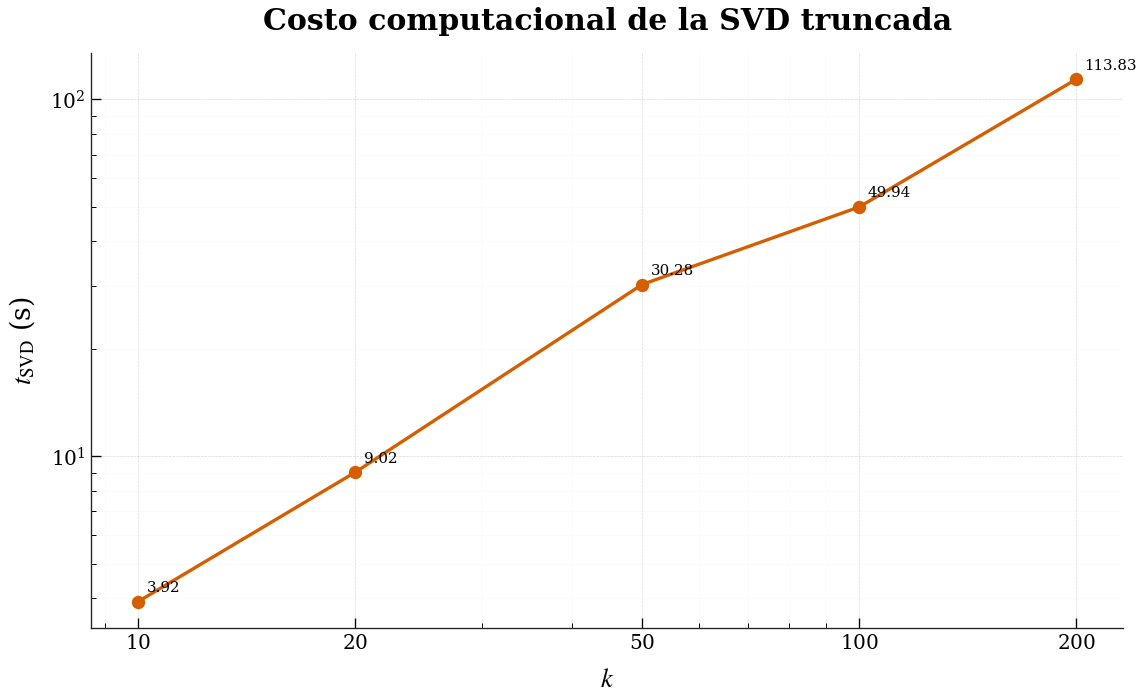

Gráfica guardada: 13_costo_computacional_svd_segun_k.png y 13_costo_computacional_svd_segun_k.pdf


,k,captured_energy,relative_error
0,10,0.323050,0.822770
1,20,0.362813,0.798240
2,30,0.386669,0.783155
3,50,0.418113,0.762815
4,75,0.445421,0.744700
5,100,0.466754,0.730237


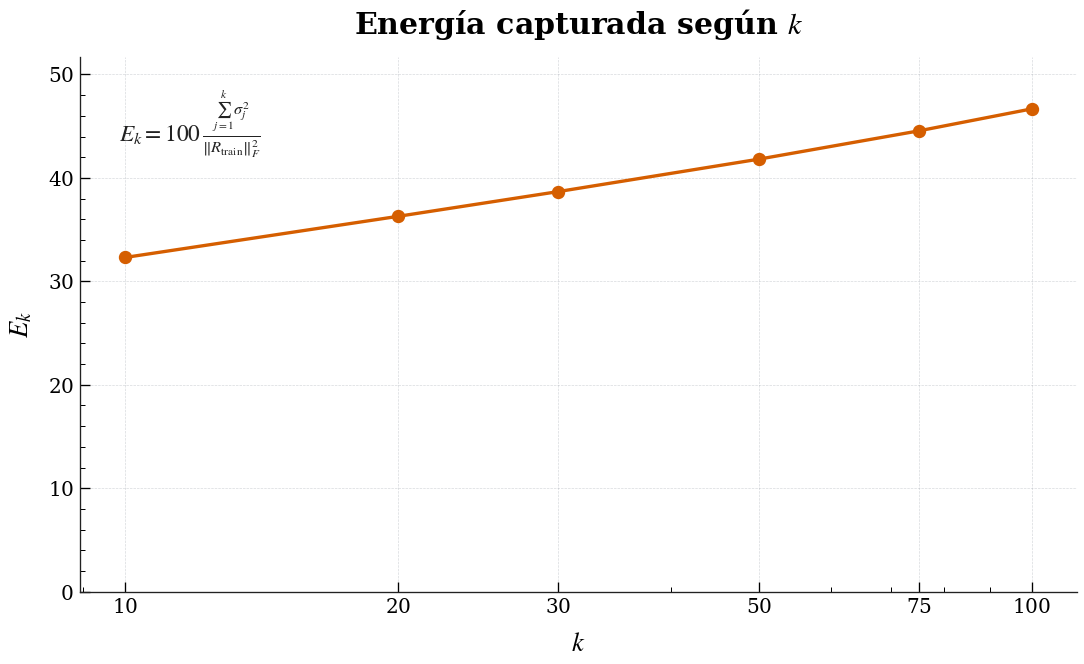

Gráfica guardada: 14_energia_segun_k.png y 14_energia_segun_k.pdf


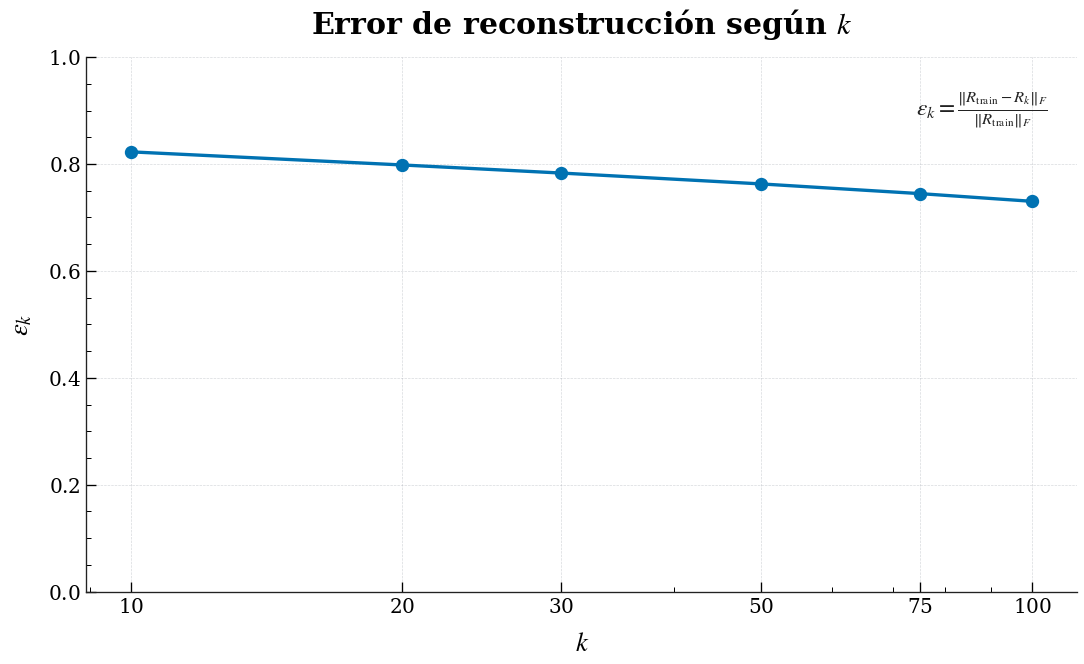

Gráfica guardada: 15_error_reconstruccion_segun_k.png y 15_error_reconstruccion_segun_k.pdf
Baseline calculado sobre los mismos 100 usuarios del estudio de k.


,Métrica,Popularidad
0,HitRate@10,0.810000
1,Precision@10,0.320000
2,Recall@10,0.076923
3,NDCG@10,0.339582
4,Cobertura,0.000155


Evaluando recomendaciones con k=10...
Evaluando recomendaciones con k=20...
Evaluando recomendaciones con k=30...
Evaluando recomendaciones con k=50...
Evaluando recomendaciones con k=75...
Evaluando recomendaciones con k=100...


,k,hitrate,precision,recall,ndcg,catalog_coverage,evaluation_time_seconds,mean_time_per_user,median_condition_number
0,10,0.60,0.202,0.046143,0.219368,0.004224,0.454815,0.004548,4.320778e+06
1,20,0.77,0.283,0.073701,0.302205,0.004314,0.698502,0.006985,4.571463e+06
2,30,0.75,0.302,0.078013,0.319576,0.004405,1.238440,0.012384,4.671483e+06
3,50,0.77,0.327,0.087209,0.343457,0.004482,2.271833,0.022718,4.850947e+06
4,75,0.78,0.335,0.089563,0.348655,0.004547,3.786655,0.037867,5.097333e+06
5,100,0.79,0.335,0.090139,0.346716,0.004469,6.322919,0.063229,5.249238e+06


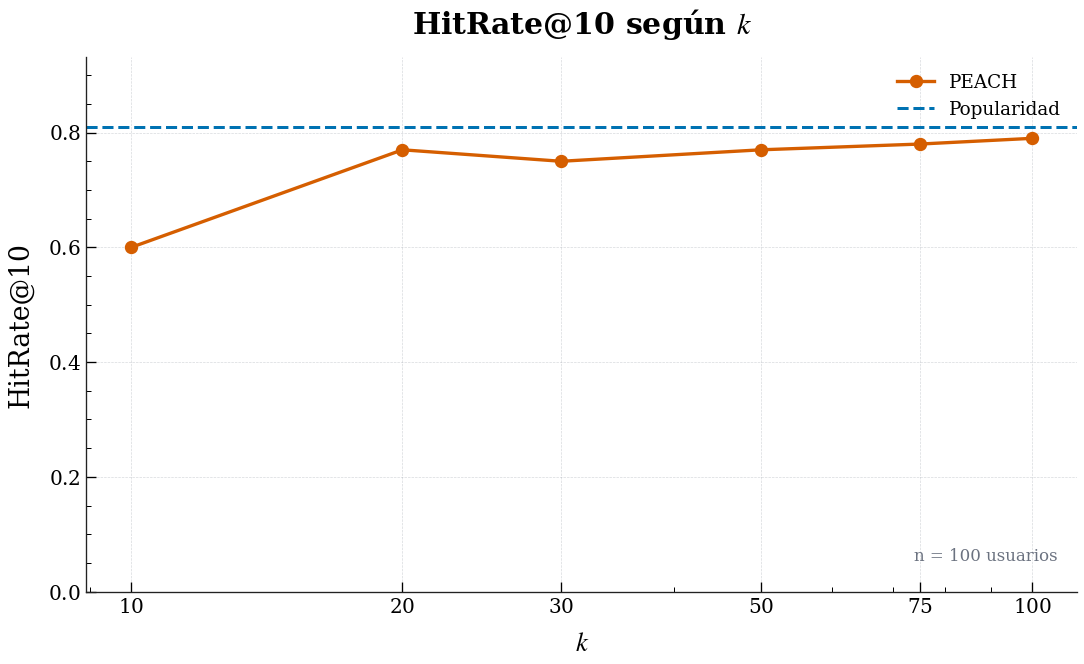

Gráfica guardada: metrica_hitrate_segun_k.png y metrica_hitrate_segun_k.pdf


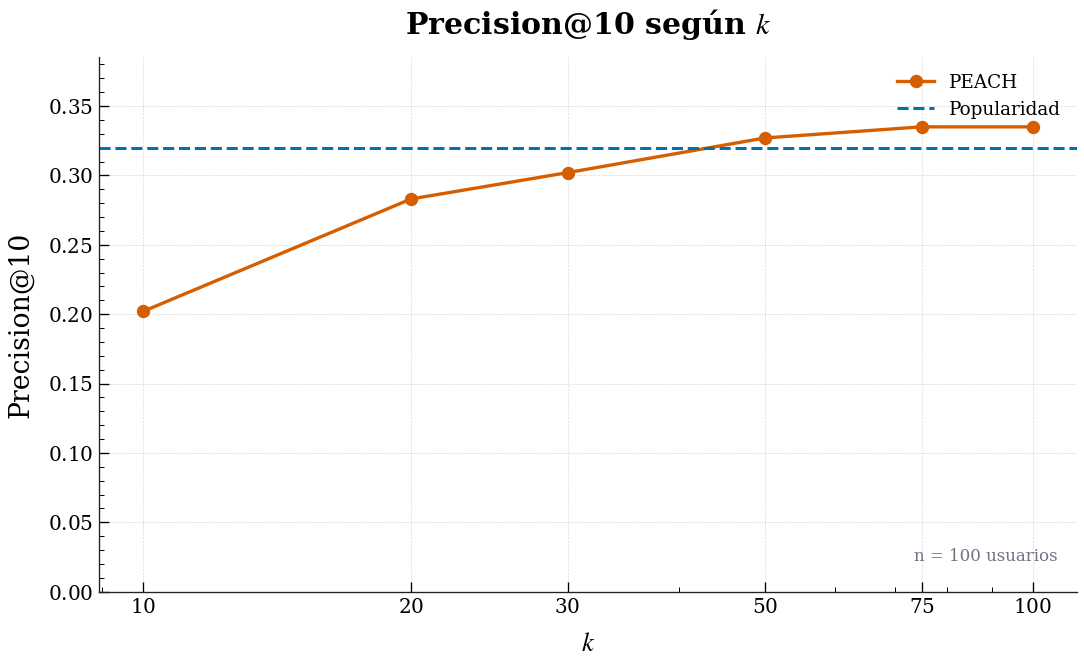

Gráfica guardada: metrica_precision_segun_k.png y metrica_precision_segun_k.pdf


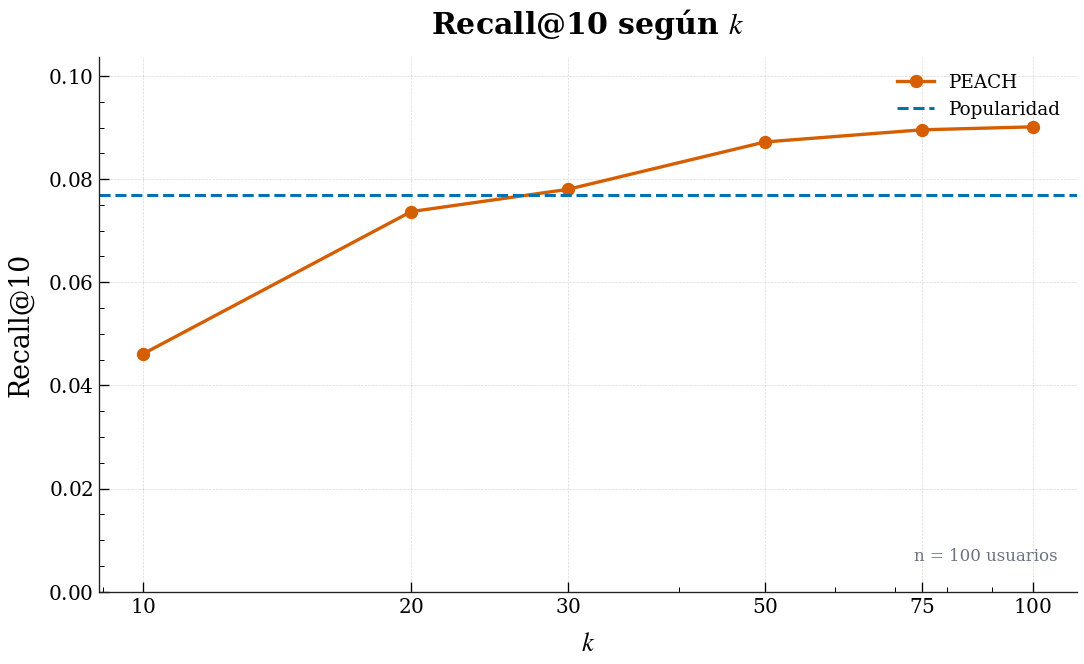

Gráfica guardada: metrica_recall_segun_k.png y metrica_recall_segun_k.pdf


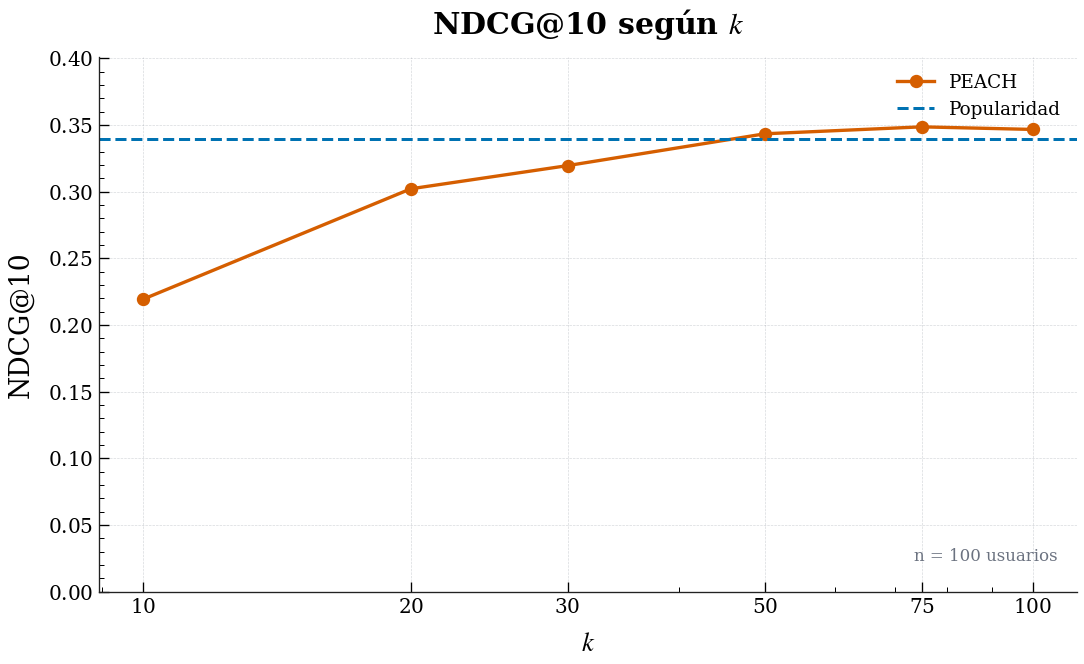

Gráfica guardada: metrica_ndcg_segun_k.png y metrica_ndcg_segun_k.pdf


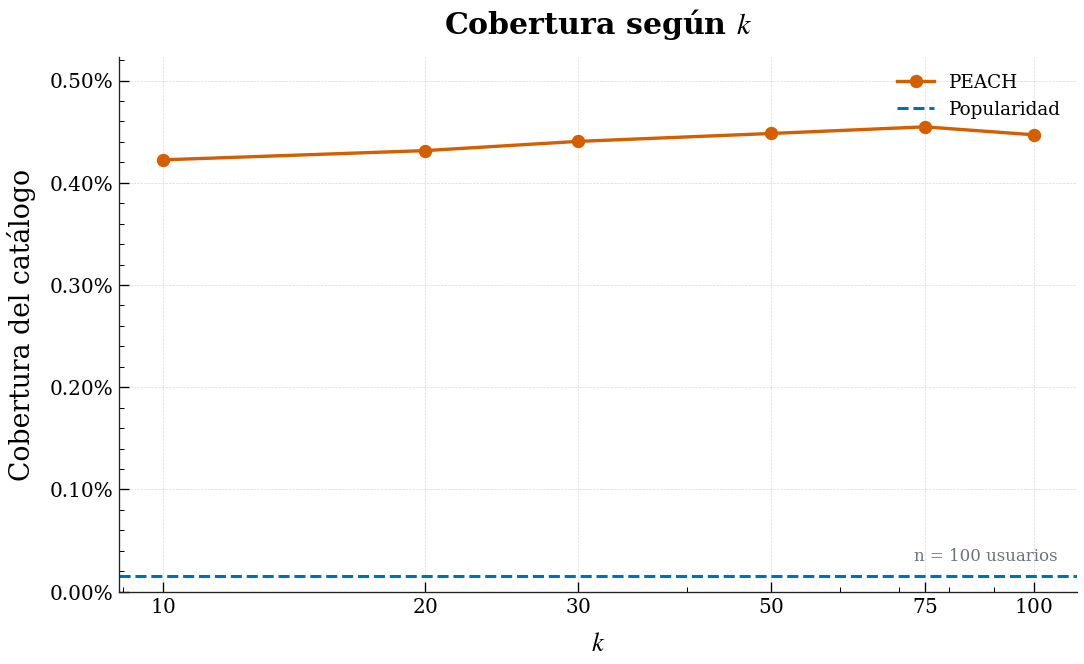

Gráfica guardada: 20_cobertura_catalogo_segun_k.png y 20_cobertura_catalogo_segun_k.pdf


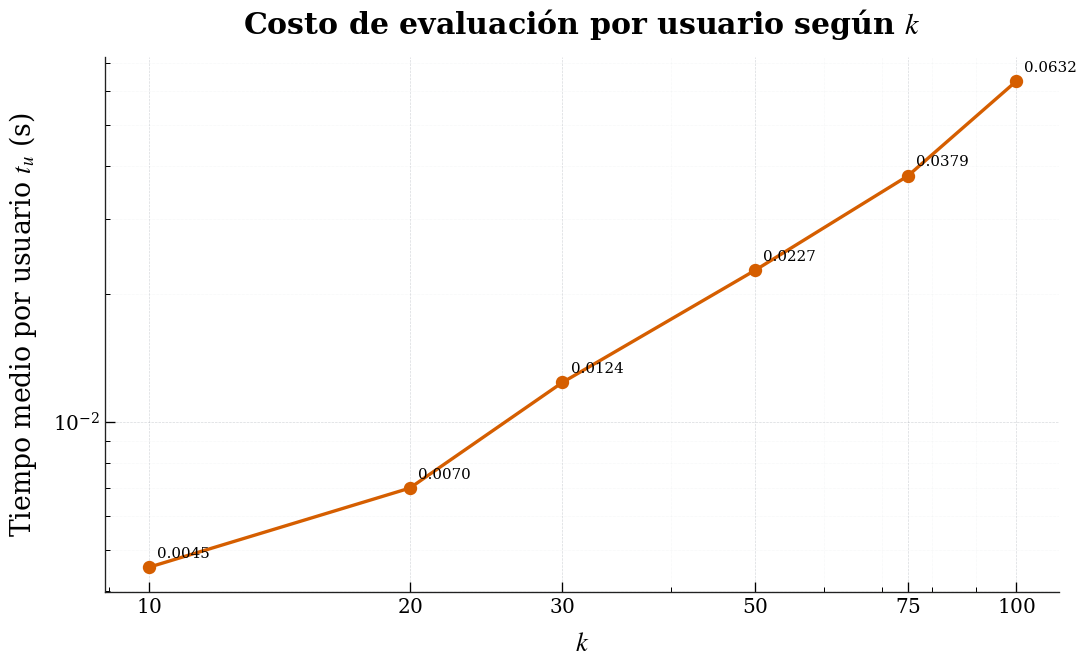

Gráfica guardada: 21_tiempo_por_usuario_segun_k.png y 21_tiempo_por_usuario_segun_k.pdf


PosixPath('/content/graficas_peach_final/21_tiempo_por_usuario_segun_k.png')

In [78]:


# ============================================================
# VALIDACIÓN DE LOS VALORES DE K
# ============================================================

MAX_K_STUDY = max(K_STUDY_VALUES)

assert MAX_K_STUDY in K_TIMING_VALUES
assert MAX_K_STUDY < min(R_train.shape)


# ============================================================
# TIEMPO REAL DE LA SVD PARA DISTINTOS K
# ============================================================

svd_timing_rows = []

S_study = None
Vt_study = None

for k_value in K_TIMING_VALUES:
    print(
        f"Calculando SVD para k={k_value}..."
    )

    start_time = time.perf_counter()

    (
        U_temporary,
        S_temporary,
        Vt_temporary
    ) = svds(
        R_train,
        k=k_value
    )

    elapsed_time = (
        time.perf_counter()
        - start_time
    )

    order = np.argsort(
        S_temporary
    )[::-1]

    S_temporary = (
        S_temporary[
            order
        ]
    )

    Vt_temporary = (
        Vt_temporary[
            order,
            :
        ]
    )

    svd_timing_rows.append({
        "k": k_value,
        "time_seconds": elapsed_time
    })

    if k_value == MAX_K_STUDY:
        S_study = np.asarray(
            S_temporary,
            dtype=np.float64
        )

        Vt_study = np.asarray(
            Vt_temporary,
            dtype=np.float32
        )

    del U_temporary
    del S_temporary
    del Vt_temporary

    gc.collect()


svd_timing_results = pd.DataFrame(
    svd_timing_rows
)

display(
    svd_timing_results
)


# ============================================================
# GRÁFICA 9: COSTO COMPUTACIONAL DE LA SVD
# ============================================================

fig, ax = plt.subplots(
    figsize=(9.5, 5.8),
    layout="constrained"
)

ax.loglog(
    svd_timing_results[
        "k"
    ],
    svd_timing_results[
        "time_seconds"
    ],
    color=PEACH_ORANGE,
    marker="o",
    markersize=7,
    linewidth=2.0
)

ax.set_xlabel(
    r"$k$"
)

ax.set_ylabel(
    r"$t_{\mathrm{SVD}}$ (s)"
)

ax.set_title(
    "Costo computacional de la SVD truncada"
)

configurar_eje_log_x(
    ax,
    K_TIMING_VALUES
)

for k_value, time_value in zip(
    svd_timing_results[
        "k"
    ],
    svd_timing_results[
        "time_seconds"
    ]
):
    ax.annotate(
        f"{time_value:.2f}",
        xy=(
            k_value,
            time_value
        ),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=9
    )

aplicar_estilo_cientifico(
    ax,
    eje_cuadricula="both",
    cuadricula_menor=True
)

guardar_y_mostrar(
    "13_costo_computacional_svd_segun_k"
)


# ============================================================
# MATRIZ DE PELÍCULAS HASTA MAX_K_STUDY
# ============================================================

assert S_study is not None
assert Vt_study is not None

Q_study_max = (
    S_study[:, None]
    * Vt_study
).T

Q_study_max = np.asarray(
    Q_study_max,
    dtype=np.float32
)

assert Q_study_max.shape == (
    len(model_movie_ids),
    MAX_K_STUDY
)


# ============================================================
# ENERGÍA Y ERROR PARA LOS K ESTUDIADOS
# ============================================================

k_numerical_rows = []

for k_value in K_STUDY_VALUES:
    energy_value = float(
        np.sum(
            S_study[
                :k_value
            ] ** 2
        )
        / frobenius_squared
    )

    error_value = float(
        np.sqrt(
            max(
                0.0,
                1.0 - energy_value
            )
        )
    )

    k_numerical_rows.append({
        "k": k_value,
        "captured_energy": energy_value,
        "relative_error": error_value
    })


k_numerical_results = pd.DataFrame(
    k_numerical_rows
)

display(
    k_numerical_results
)


# ============================================================
# GRÁFICA 10: ENERGÍA SEGÚN K
# ============================================================

energy_percent_by_k = (
    100.0
    * k_numerical_results[
        "captured_energy"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained"
)

ax.semilogx(
    k_numerical_results[
        "k"
    ],
    energy_percent_by_k,
    color=PEACH_ORANGE,
    marker="o",
    markersize=7,
    linewidth=2.0
)

ax.set_xlabel(
    r"$k$"
)

ax.set_ylabel(
    r"$E_k$"
)

ax.set_title(
    r"Energía capturada según $k$"
)

ax.set_ylim(
    0,
    min(
        100.0,
        energy_percent_by_k.max()
        + 5.0
    )
)

configurar_eje_log_x(
    ax,
    K_STUDY_VALUES
)

ax.text(
    0.04,
    0.94,
    (
        r"$E_k="
        r"100\,"
        r"\frac{\sum_{j=1}^{k}\sigma_j^2}"
        r"{\Vert R_{\mathrm{train}}\Vert_F^2}$"
    ),
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=14,
    color=PEACH_DARK
)

aplicar_estilo_cientifico(
    ax
)

guardar_y_mostrar(
    "14_energia_segun_k"
)


# ============================================================
# GRÁFICA 11: ERROR SEGÚN K
# ============================================================

k_error_values = (
    k_numerical_results[
        "k"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

relative_error_values = (
    k_numerical_results[
        "relative_error"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

valid_error_mask = (
    np.isfinite(
        k_error_values
    )
    & np.isfinite(
        relative_error_values
    )
    & (
        k_error_values > 0
    )
)

k_error_plot = (
    k_error_values[
        valid_error_mask
    ]
)

relative_error_plot = (
    relative_error_values[
        valid_error_mask
    ]
)

if k_error_plot.size == 0:
    raise RuntimeError(
        "No existen datos válidos para representar "
        "el error de reconstrucción según k."
    )


fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained"
)

ax.semilogx(
    k_error_plot,
    relative_error_plot,
    color=POPULARITY_BLUE,
    marker="o",
    markersize=7,
    linewidth=2.0
)

ax.set_xlabel(
    r"$k$"
)

ax.set_ylabel(
    r"$\varepsilon_k$"
)

ax.set_title(
    r"Error de reconstrucción según $k$"
)

ax.set_ylim(
    0,
    1
)

configurar_eje_log_x(
    ax,
    K_STUDY_VALUES
)

ax.text(
    0.97,
    0.94,
    (
        r"$\varepsilon_k="
        r"\frac{\Vert R_{\mathrm{train}}-R_k\Vert_F}"
        r"{\Vert R_{\mathrm{train}}\Vert_F}$"
    ),
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=14,
    color=PEACH_DARK
)

aplicar_estilo_cientifico(
    ax,
    eje_cuadricula="both"
)

guardar_y_mostrar(
    "15_error_reconstruccion_segun_k"
)


# ============================================================
# USUARIOS PARA EL ESTUDIO DE K
# ============================================================

n_k_users = min(
    N_K_STUDY_USERS,
    len(selected_test_user_ids)
)

k_study_user_ids = (
    selected_test_user_ids[
        :n_k_users
    ]
)

k_study_splits = {
    int(user_id): (
        prepare_test_user_history(
            user_id=int(
                user_id
            ),
            user_history=(
                evaluation_histories[
                    int(user_id)
                ]
            )
        )
    )
    for user_id
    in k_study_user_ids
}


# ============================================================
# BASELINE DE POPULARIDAD SOBRE LOS MISMOS USUARIOS
# ============================================================

k_popularity_rows = []

k_unique_popularity_recommendations = set()

for user_id in k_study_user_ids:
    user_id = int(
        user_id
    )

    test_split = (
        k_study_splits[
            user_id
        ]
    )

    popularity_recommendations = (
        recommend_popularity_top_k(
            observed_movie_ids=(
                test_split[
                    "observed_movie_ids"
                ]
            ),
            popularity_movie_ids=(
                popularity_movie_ids
            ),
            top_k=TOP_K
        )
    )

    popularity_metrics = (
        compute_ranking_metrics(
            recommended_movie_ids=(
                popularity_recommendations
            ),
            relevant_movie_ids=(
                test_split[
                    "relevant_hidden_ids"
                ]
            ),
            top_k=TOP_K
        )
    )

    k_unique_popularity_recommendations.update(
        int(movie_id)
        for movie_id
        in popularity_recommendations
    )

    k_popularity_rows.append({
        "userId": user_id,
        "hitrate": (
            popularity_metrics[
                "hitrate"
            ]
        ),
        "precision": (
            popularity_metrics[
                "precision"
            ]
        ),
        "recall": (
            popularity_metrics[
                "recall"
            ]
        ),
        "ndcg": (
            popularity_metrics[
                "ndcg"
            ]
        )
    })


k_popularity_results = pd.DataFrame(
    k_popularity_rows
)

if k_popularity_results.empty:
    raise RuntimeError(
        "No fue posible evaluar el baseline de popularidad "
        "sobre los usuarios del estudio de k."
    )


k_popularity_summary = {
    metric_name: float(
        k_popularity_results[
            metric_name
        ].mean()
    )
    for metric_name in (
        "hitrate",
        "precision",
        "recall",
        "ndcg"
    )
}


k_popularity_coverage = (
    len(
        k_unique_popularity_recommendations
    )
    / len(
        model_movie_ids
    )
)


k_popularity_summary_df = pd.DataFrame({
    "Métrica": [
        "HitRate@10",
        "Precision@10",
        "Recall@10",
        "NDCG@10",
        "Cobertura"
    ],
    "Popularidad": [
        k_popularity_summary[
            "hitrate"
        ],
        k_popularity_summary[
            "precision"
        ],
        k_popularity_summary[
            "recall"
        ],
        k_popularity_summary[
            "ndcg"
        ],
        k_popularity_coverage
    ]
})


print(
    "Baseline calculado sobre los mismos",
    len(
        k_study_user_ids
    ),
    "usuarios del estudio de k."
)

display(
    k_popularity_summary_df.round(
        6
    )
)


# ============================================================
# EVALUACIÓN DE PEACH PARA CADA K
# ============================================================

k_metric_rows = []

k_summary_rows = []

for k_value in K_STUDY_VALUES:
    print(
        f"Evaluando recomendaciones con k={k_value}..."
    )

    Q_k = np.asarray(
        Q_study_max[
            :,
            :k_value
        ],
        dtype=np.float32
    )

    k_start = time.perf_counter()

    unique_recommendations = set()

    user_metric_rows = []

    for user_id in k_study_user_ids:
        user_id = int(
            user_id
        )

        test_split = (
            k_study_splits[
                user_id
            ]
        )

        (
            p_user_k,
            condition_k
        ) = estimate_test_user_profile(
            observed_movie_ids=(
                test_split[
                    "observed_movie_ids"
                ]
            ),
            observed_ratings=(
                test_split[
                    "observed_ratings"
                ]
            ),
            Q=Q_k,
            movie_id_to_col=(
                movie_id_to_col
            ),
            lambda_reg=LAMBDA_REG
        )

        (
            recommendations_k,
            _
        ) = recommend_peach_top_k(
            p_user=p_user_k,
            observed_movie_ids=(
                test_split[
                    "observed_movie_ids"
                ]
            ),
            Q=Q_k,
            model_movie_ids=(
                model_movie_ids
            ),
            movie_id_to_col=(
                movie_id_to_col
            ),
            top_k=TOP_K
        )

        metrics_k = (
            compute_ranking_metrics(
                recommended_movie_ids=(
                    recommendations_k
                ),
                relevant_movie_ids=(
                    test_split[
                        "relevant_hidden_ids"
                    ]
                ),
                top_k=TOP_K
            )
        )

        unique_recommendations.update(
            int(movie_id)
            for movie_id
            in recommendations_k
        )

        user_metric_rows.append({
            "userId": user_id,
            "k": k_value,
            "hitrate": (
                metrics_k[
                    "hitrate"
                ]
            ),
            "precision": (
                metrics_k[
                    "precision"
                ]
            ),
            "recall": (
                metrics_k[
                    "recall"
                ]
            ),
            "ndcg": (
                metrics_k[
                    "ndcg"
                ]
            ),
            "condition_number": (
                condition_k
            )
        })

    k_elapsed = (
        time.perf_counter()
        - k_start
    )

    k_metric_rows.extend(
        user_metric_rows
    )

    user_metric_df = pd.DataFrame(
        user_metric_rows
    )

    if user_metric_df.empty:
        raise RuntimeError(
            f"No se obtuvieron resultados para k={k_value}."
        )

    k_summary_rows.append({
        "k": k_value,

        "hitrate": float(
            user_metric_df[
                "hitrate"
            ].mean()
        ),

        "precision": float(
            user_metric_df[
                "precision"
            ].mean()
        ),

        "recall": float(
            user_metric_df[
                "recall"
            ].mean()
        ),

        "ndcg": float(
            user_metric_df[
                "ndcg"
            ].mean()
        ),

        "catalog_coverage": (
            len(
                unique_recommendations
            )
            / len(
                model_movie_ids
            )
        ),

        "evaluation_time_seconds": (
            k_elapsed
        ),

        "mean_time_per_user": (
            k_elapsed
            / len(
                user_metric_df
            )
        ),

        "median_condition_number": float(
            user_metric_df[
                "condition_number"
            ].median()
        )
    })

    del Q_k

    gc.collect()


k_metric_results = pd.DataFrame(
    k_metric_rows
)

k_study_summary = pd.DataFrame(
    k_summary_rows
)

display(
    k_study_summary.round(
        6
    )
)


# ============================================================
# DEFINICIONES DE LAS MÉTRICAS
# ============================================================

metric_plot_definitions = [
    (
        "hitrate",
        "HitRate@10"
    ),
    (
        "precision",
        "Precision@10"
    ),
    (
        "recall",
        "Recall@10"
    ),
    (
        "ndcg",
        "NDCG@10"
    )
]


# ============================================================
# GRÁFICAS 12–15: PEACH VS. POPULARIDAD SEGÚN K
# ============================================================

for (
    column_name,
    metric_label
) in metric_plot_definitions:

    metric_values = (
        k_study_summary[
            column_name
        ]
        .to_numpy(
            dtype=np.float64
        )
    )

    popularity_value = float(
        k_popularity_summary[
            column_name
        ]
    )

    fig, ax = plt.subplots(
        figsize=(9, 5.5),
        layout="constrained"
    )

    ax.semilogx(
        k_study_summary[
            "k"
        ],
        metric_values,
        color=PEACH_ORANGE,
        marker="o",
        markersize=7,
        linewidth=2.0,
        label="PEACH"
    )

    ax.axhline(
        popularity_value,
        color=POPULARITY_BLUE,
        linestyle="--",
        linewidth=1.8,
        label="Popularidad"
    )

    ax.set_xlabel(
        r"$k$"
    )

    ax.set_ylabel(
        metric_label
    )

    ax.set_title(
        rf"{metric_label} según $k$"
    )

    upper_value = max(
        float(
            metric_values.max()
        ),
        popularity_value
    )

    ax.set_ylim(
        0,
        min(
            1.0,
            max(
                0.05,
                1.15
                * upper_value
            )
        )
    )

    configurar_eje_log_x(
        ax,
        K_STUDY_VALUES
    )

    ax.text(
        0.98,
        0.05,
        (
            f"n = "
            f"{len(k_study_user_ids)} "
            "usuarios"
        ),
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=10,
        color=PEACH_GRAY
    )

    ax.legend(
        loc="best",
        frameon=False
    )

    aplicar_estilo_cientifico(
        ax
    )

    guardar_y_mostrar(
        f"metrica_{column_name}_segun_k"
    )


# ============================================================
# GRÁFICA 16: COBERTURA SEGÚN K
# ============================================================

coverage_percent_by_k = (
    100.0
    * k_study_summary[
        "catalog_coverage"
    ]
    .to_numpy(
        dtype=np.float64
    )
)

popularity_coverage_percent = (
    100.0
    * k_popularity_coverage
)


fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained"
)

ax.semilogx(
    k_study_summary[
        "k"
    ],
    coverage_percent_by_k,
    color=PEACH_ORANGE,
    marker="o",
    markersize=7,
    linewidth=2.0,
    label="PEACH"
)

ax.axhline(
    popularity_coverage_percent,
    color=POPULARITY_BLUE,
    linestyle="--",
    linewidth=1.8,
    label="Popularidad"
)

ax.set_xlabel(
    r"$k$"
)

ax.set_ylabel(
    "Cobertura del catálogo"
)

ax.set_title(
    r"Cobertura según $k$"
)

coverage_upper_value = max(
    float(
        coverage_percent_by_k.max()
    ),
    float(
        popularity_coverage_percent
    )
)

ax.set_ylim(
    0,
    max(
        0.01,
        1.15
        * coverage_upper_value
    )
)

ax.yaxis.set_major_formatter(
    PercentFormatter(
        xmax=100,
        decimals=2
    )
)

configurar_eje_log_x(
    ax,
    K_STUDY_VALUES
)

ax.text(
    0.98,
    0.05,
    (
        f"n = "
        f"{len(k_study_user_ids)} "
        "usuarios"
    ),
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    color=PEACH_GRAY
)

ax.legend(
    loc="best",
    frameon=False
)

aplicar_estilo_cientifico(
    ax
)

guardar_y_mostrar(
    "20_cobertura_catalogo_segun_k"
)


# ============================================================
# GRÁFICA 17: TIEMPO MEDIO POR USUARIO SEGÚN K
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 5.5),
    layout="constrained"
)

ax.loglog(
    k_study_summary[
        "k"
    ],
    k_study_summary[
        "mean_time_per_user"
    ],
    color=PEACH_ORANGE,
    marker="o",
    markersize=7,
    linewidth=2.0
)

ax.set_xlabel(
    r"$k$"
)

ax.set_ylabel(
    r"Tiempo medio por usuario $t_u$ (s)"
)

ax.set_title(
    r"Costo de evaluación por usuario según $k$"
)

configurar_eje_log_x(
    ax,
    K_STUDY_VALUES
)

for k_value, time_value in zip(
    k_study_summary[
        "k"
    ],
    k_study_summary[
        "mean_time_per_user"
    ]
):
    ax.annotate(
        f"{time_value:.4f}",
        xy=(
            k_value,
            time_value
        ),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=9
    )

aplicar_estilo_cientifico(
    ax,
    eje_cuadricula="both",
    cuadricula_menor=True
)

guardar_y_mostrar(
    "21_tiempo_por_usuario_segun_k"
)

## 17. Validación final del experimento

Las siguientes comprobaciones garantizan que:

- Los usuarios evaluados no participaron en el entrenamiento.
- Cada usuario reveló exactamente cinco ratings.
- Cada usuario conservó al menos una película positiva oculta.
- Los rankings contienen diez películas.
- Las películas observadas no aparecen en las recomendaciones.
- Todas las métricas pertenecen al intervalo $[0,1]$.

In [79]:
# ============================================================
# VALIDACIONES FINALES
# ============================================================

assert len(
    evaluation_results
) == n_users_to_evaluate

assert (
    evaluation_results[
        "n_observed"
    ]
    == N_OBSERVED_RATINGS
).all()

assert (
    evaluation_results[
        "n_hidden_positive"
    ]
    >= 1
).all()

metric_columns = [
    "peach_hitrate",
    "peach_precision",
    "peach_recall",
    "peach_ndcg",
    "popularity_hitrate",
    "popularity_precision",
    "popularity_recall",
    "popularity_ndcg"
]

for column in metric_columns:
    assert evaluation_results[
        column
    ].between(
        0.0,
        1.0
    ).all()

for row in evaluation_results.itertuples(
    index=False
):
    observed_set = set(
        row.observed_movie_ids
    )

    assert len(
        row.peach_recommendations
    ) == TOP_K

    assert len(
        row.popularity_recommendations
    ) == TOP_K

    assert observed_set.isdisjoint(
        set(
            row.peach_recommendations
        )
    )

    assert observed_set.isdisjoint(
        set(
            row.popularity_recommendations
        )
    )

    assert len(
        row.relevant_hidden_ids
    ) >= 1

evaluated_user_set = set(
    evaluation_results[
        "userId"
    ].tolist()
)

assert evaluated_user_set.isdisjoint(
    train_user_set
)

print(
    "Usuarios evaluados:",
    len(evaluation_results)
)

print(
    "Usuarios evaluados presentes "
    "en entrenamiento:",
    0
)

print(
    "Ratings observados por usuario:",
    N_OBSERVED_RATINGS
)

print(
    "Tamaño de cada ranking:",
    TOP_K
)

print(
    "Películas candidatas:",
    len(model_movie_ids)
)

print(
    "\n✅ Evaluación de Peach completada "
    "sin fuga de información."
)

print(
    "✅ Métricas de Peach y popularidad "
    "calculadas correctamente."
)

Usuarios evaluados: 500
Usuarios evaluados presentes en entrenamiento: 0
Ratings observados por usuario: 5
Tamaño de cada ranking: 10
Películas candidatas: 77416

✅ Evaluación de Peach completada sin fuga de información.
✅ Métricas de Peach y popularidad calculadas correctamente.


In [80]:
# ============================================================
# VALIDACIONES DEL ESTUDIO NUMÉRICO
# ============================================================

assert set(
    K_STUDY_VALUES
) == set(
    k_study_summary["k"]
)

assert (
    k_study_summary[
        [
            "hitrate",
            "precision",
            "recall",
            "ndcg",
            "catalog_coverage"
        ]
    ]
    .apply(
        lambda column: column.between(
            0.0,
            1.0
        ).all()
    )
    .all()
)

assert (
    k_numerical_results[
        "captured_energy"
    ]
    .is_monotonic_increasing
)

assert (
    k_numerical_results[
        "relative_error"
    ]
    .is_monotonic_decreasing
)

assert (
    condition_results[
        "condition_with_regularization"
    ]
    .replace(
        [
            np.inf,
            -np.inf
        ],
        np.nan
    )
    .notna()
    .all()
)

print(
    "✅ Estudio de sensibilidad respecto "
    "a k completado."
)

print(
    "✅ Diagnóstico de condicionamiento "
    "completado."
)

print(
    "✅ Gráficas experimentales "
    "preparadas correctamente."
)

✅ Estudio de sensibilidad respecto a k completado.
✅ Diagnóstico de condicionamiento completado.
✅ Gráficas experimentales preparadas correctamente.


In [81]:
# ============================================================
# VERIFICAR GRÁFICAS GUARDADAS
# ============================================================

graficas_guardadas = sorted(
    GRAPH_DIR.glob("*.png")
)

print(
    "Cantidad de gráficas guardadas:",
    len(graficas_guardadas)
)

for grafica in graficas_guardadas:
    print(
        "-",
        grafica.name
    )

Cantidad de gráficas guardadas: 21
- 01_distribucion_ratings.png
- 02_peach_vs_popularidad.png
- 03_diferencia_peach_popularidad.png
- 04_cobertura_peach_vs_popularidad.png
- 05_espectro_singular.png
- 06_espectro_singular_logaritmico.png
- 07_aporte_individual_energia.png
- 08_energia_acumulada.png
- 09_error_relativo_reconstruccion.png
- 10_condicionamiento_sin_regularizacion.png
- 11_condicionamiento_con_regularizacion.png
- 12_condicionamiento_segun_lambda.png
- 13_costo_computacional_svd_segun_k.png
- 14_energia_segun_k.png
- 15_error_reconstruccion_segun_k.png
- 20_cobertura_catalogo_segun_k.png
- 21_tiempo_por_usuario_segun_k.png
- metrica_hitrate_segun_k.png
- metrica_ndcg_segun_k.png
- metrica_precision_segun_k.png
- metrica_recall_segun_k.png


In [82]:
# ============================================================
# COMPRIMIR Y DESCARGAR LAS GRÁFICAS
# ============================================================

import shutil

from google.colab import files


graficas_guardadas = sorted(
    GRAPH_DIR.glob("*.png")
)

if not graficas_guardadas:
    raise RuntimeError(
        "No hay gráficas guardadas. "
        "Ejecuta primero las celdas que generan las figuras."
    )

zip_base = Path(
    "/content/graficas_peach_final"
)

zip_path = Path(
    str(zip_base) + ".zip"
)

if zip_path.exists():
    zip_path.unlink()

archivo_generado = shutil.make_archive(
    base_name=str(zip_base),
    format="zip",
    root_dir=str(GRAPH_DIR)
)

print(
    f"✅ Se comprimieron "
    f"{len(graficas_guardadas)} gráficas."
)

print(
    "Archivo:",
    archivo_generado
)

files.download(
    archivo_generado
)

✅ Se comprimieron 21 gráficas.
Archivo: /content/graficas_peach_final.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Referencias

- Harper, F. M., & Konstan, J. A. (2015). *The MovieLens Datasets: History and Context*. ACM Transactions on Interactive Intelligent Systems, 5(4), 1–19. https://doi.org/10.1145/2827872
- GroupLens Research. (2024). *MovieLens 32M Dataset*. University of Minnesota. https://grouplens.org/datasets/movielens/32m/
- Golub, G. H., & Van Loan, C. F. (2013). *Matrix Computations* (4th ed.). Johns Hopkins University Press.
- Trefethen, L. N., & Bau, D. (1997). *Numerical Linear Algebra*. SIAM.
- Boyd, S., & Vandenberghe, L. (2018). *Introduction to Applied Linear Algebra: Vectors, Matrices, and Least Squares*. Cambridge University Press.